
This is code that:
1. Generates a matrix with varying degrees of nestedness or modularity
2. Samples uniformly at random some species from the matrices, runs deterministic GLV, and stores simulated data
3. Calculates co-occurrence matrix as covariance between abundance vectors
4. Calculates nestedness (NODF) or Qb (Barbers' modularity Qb) of both original and co-occurrence graphs and compares similarity
5. For modular networks, computes pairwise clustering accuracy 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import networkx as nx
from networkx.algorithms import bipartite
from sklearn import metrics
from sklearn.metrics import r2_score
from scipy import stats
from scipy import sparse
from scipy.stats import rankdata
from scipy.stats import bootstrap
from cdlib import algorithms
import statsmodels.api as sm
from scipy.optimize import curve_fit
import math
from scipy.stats import linregress
import seaborn as sns
import pandas as pd

import metaCommunityMx
import community_sim
import metrics_and_plotting
import run_cooccurrence
reload(metaCommunityMx)
reload(community_sim)
reload(metrics_and_plotting)
reload(run_cooccurrence)

<module 'run_cooccurrence' from '/Users/claireevensen/CooccurCollab/TheoryCoOccur/run_cooccurrence.py'>

In [ ]:
# Comparing NODF values for various cutoffs with one p(interact) and one p(+) --> Shows absolute NODF value is very dependent on density of fill, as expected
#Essentially no correlation beyond that given by link density(co-occurrence has few edges


pPositive = 0.3
pInteract = 0.4 
nSpec = 100
interactStren = 0.01
# parms for GLV sim
alpha = 0.05 
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500
b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))

#to get a range of initial nestedness values; how long to run SOM model
num_its = np.random.choice(np.arange(1,30000),75)
cutoffs = [0.05, 0.1, 0.15, 0.2]

for cutoff in cutoffs:
    nodf_nest = np.zeros(len(num_its))
    nodf_cooccnest = np.zeros(len(num_its))
    for i in range(len(num_its)):
        somIter = num_its[i]
        randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)
        mx_nested = metaCommunityMx.generateNestedMatrix(randMx, SOMiterations = somIter)
        nodf_nest[i] = metrics_and_plotting.calculate_nodf(mx_nested)
        
        network_cooccnest, G_nest_coocc = run_cooccurrence.get_coocc_network(interactionMx = mx_nested, cutoff = cutoff, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b)
        nodf_cooccnest[i] = metrics_and_plotting.calculate_nodf(network_cooccnest)

         

    slope, intercept, r_value, p_value, std_err = stats.linregress(nodf_nest, nodf_cooccnest)
    r_squared = r_value**2
    x_range = np.array([0, 1])
    y_fit = slope * x_range + intercept

    plt.scatter(nodf_nest, nodf_cooccnest)
    plt.xlabel('Interaction nestedness')
    plt.ylabel('Co-abundance nestedness')
    plt.title(f'NODF Comparison (cutoff = {cutoff})')
    plt.plot(x_range, y_fit, 'g', label=f'Linear fit: y = {slope:.3f}x + {intercept:.3f}, R2 = {r_squared:.3f}')
    plt.xlim(min(nodf_nest),max(nodf_nest))
    plt.ylim(min(nodf_cooccnest), max(nodf_cooccnest))
    plt.legend()
    plt.show()





In [276]:
#In the model PRC (Probable Rows and Columns), the probability that any cell ai j shows a presence is:
#(Pi /C + Pj /R)/2, where Pi is the number of presences in row i, Pj is the number of presences in column j, C is the number of columns, and R is the number of rows. 

def nodf_interval_prc(network):
    #Probable Rows and Columns  
    nestednull = np.zeros(1000)

    nrows = network.shape[0]
    ncols = network.shape[1]
    rowsums = np.sum(network, axis = 1)
    colsums = np.sum(network, axis = 0)
    for k in range(len(nestednull)):
        shuffled = np.zeros(shape=(nrows,ncols))
        for i in range(nrows):
            for j in range(ncols):
                pres = (rowsums[i]/ncols + colsums[j]/nrows)/2
                shuffled[i,j] = np.random.choice([0,1],p=[1-pres, pres])

        nodf_shuffle = metrics_and_plotting.calculate_nodf(shuffled)
        nestednull[k]=nodf_shuffle

    low_nodf = np.percentile(nestednull, 2.5)
    high_nodf = np.percentile(nestednull, 97.5)

    return low_nodf, high_nodf

1.0
0.10111816414877639
0.09842428659775597
0.052059863945578225 0.07185250242954325


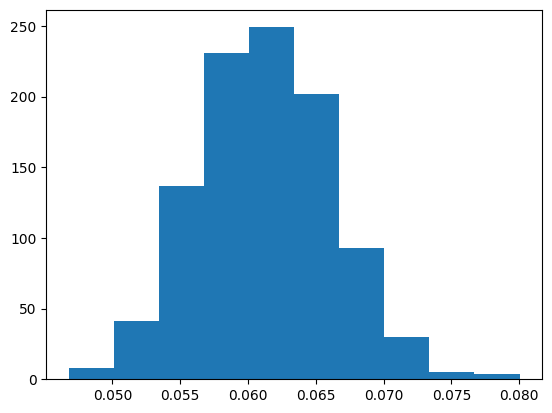

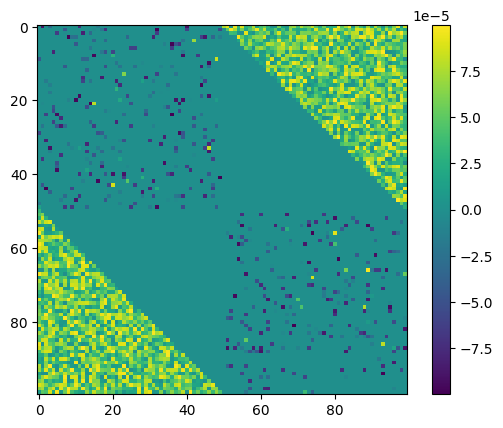

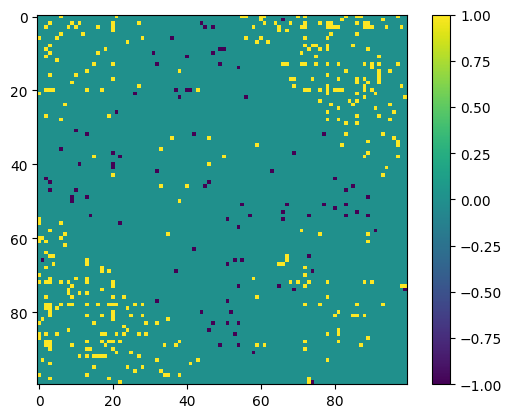

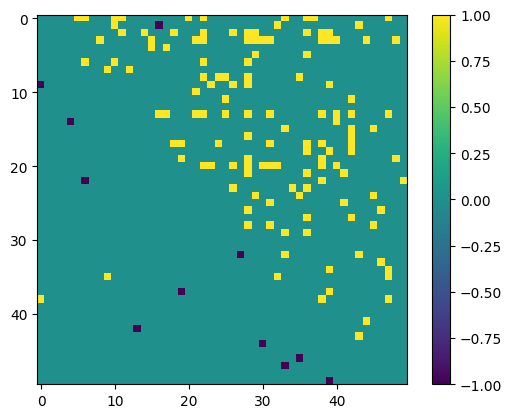

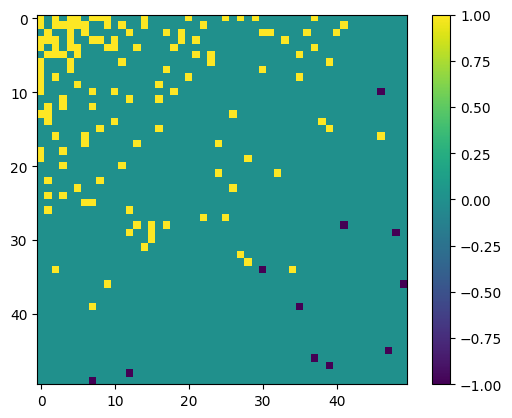

In [ ]:
#classifying as significantly nested
#scratch block
nSpecies = 100
maxInteractionStrength = 0.0001
pInterInteract = 1
pInterInteract_off = 0
pPositive = 0.1
pIntraInteract = 0.1


# parms for GLV sim
alpha = np.random.uniform(low = 0.0007, high = 0.002, size=nSpecies)
#alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))


nestedparasite = metaCommunityMx.getNestedMutual(maxInteractionStrength,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive)
#print(nestedparasite)
numgroup = int(0.5*nSpecies)
nestedonly_int = nestedparasite[0:numgroup, numgroup:nSpecies]
nodf_int = metrics_and_plotting.calculate_nodf(nestedonly_int)
#print(nestedonly_int)
print(nodf_int)

network_cooccnest, G_nest_coocc = run_cooccurrence.get_coocc_network(interactionMx = nestedparasite, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 150)
nestedonly_cooc = network_cooccnest[0:numgroup, numgroup:nSpecies]
positive_entries = np.where( nestedonly_cooc> 0, nestedonly_cooc, 0)
nodf_cooc = metrics_and_plotting.calculate_nodf(nestedonly_cooc)
nodf_pos = metrics_and_plotting.calculate_nodf(positive_entries)
print(nodf_cooc)
print(nodf_pos)



nestednull = np.zeros(1000)
for i in range(len(nestednull)):
    shuffled = nestedonly_cooc.copy()
    shuffled = shuffled.flatten()
    np.random.shuffle(shuffled)
    shuffled = shuffled.reshape(group_size,group_size)
        
    nodf_shuffle = metrics_and_plotting.calculate_nodf(shuffled)
    nestednull[i]=nodf_shuffle

low = np.percentile(nestednull, 2.5)
high = np.percentile(nestednull, 97.5)
print(low,high)

plt.hist(nestednull)
plt.show()
plt.imshow(nestedparasite)
plt.colorbar()
plt.show()
plt.imshow(network_cooccnest)
plt.colorbar()
plt.show()
plt.imshow(nestedonly_cooc)
plt.colorbar()
plt.show()

row_sums = nestedonly_cooc.sum(axis=1)
row_sort_indices = np.argsort(row_sums)[::-1]
sorted_matrix = nestedonly_cooc[row_sort_indices, :]

    # For columns (descending sum)
col_sums = sorted_matrix.sum(axis=0)
col_sort_indices = np.argsort(col_sums)[::-1]
sorted_matrix = sorted_matrix[:, col_sort_indices]

plt.imshow(sorted_matrix)
plt.colorbar()
plt.show()

#constrained = (nestedonly_cooc!= 0).astype(int)
#prc_low, prc_high = nodf_interval_prc(constrained)
#print(prc_low, prc_high)



[[0, 1, 2, 3, 4, 5, 6, 20, 21, 23, 30], [7, 9, 25, 26, 27, 28, 29], [8, 15, 16, 17, 18, 19, 37], [10, 11, 12, 13, 14, 22], [24, 31, 32, 34, 35, 36, 38, 39], [33, 45, 46, 47, 48, 49], [40, 41, 42, 43, 44]]
0.36099092602608085
[[0, 27, 30, 32, 38, 49], [1, 2, 3, 19, 47], [4, 11, 21, 22, 25, 34], [5, 29, 41, 45, 46, 48], [6, 23, 43], [7, 8, 24, 42], [9, 13, 28, 33, 37], [10, 12, 26, 40], [15, 16, 17, 18, 31], [20], [35, 36, 39, 44]]
0.11844801374843031
-0.09591017251635932 0.20633386211910934 0.16118381915526503
258


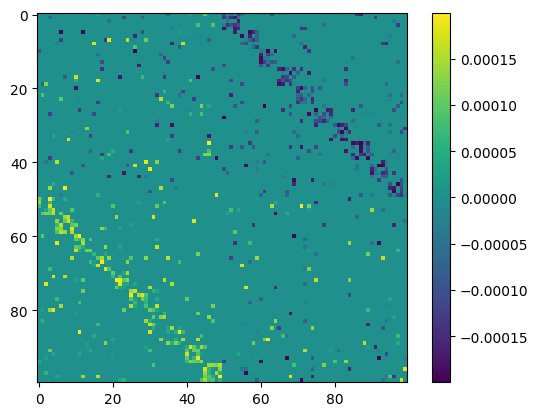

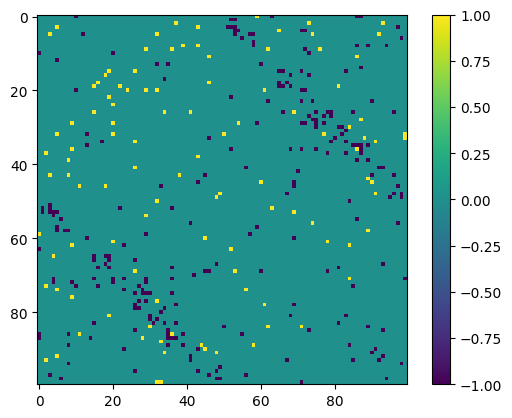

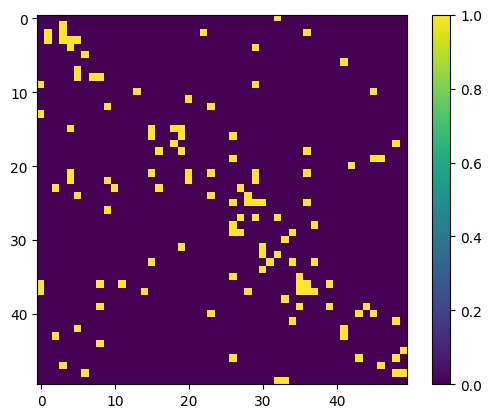

In [ ]:
#classifying as significantly modular
#scratch block
nSpecies = 100
interactFactor = 1/5
pInterInteract = .64
pInterInteract_off = 0.04
pPositive = 0.5
pIntraInteract = 0.05
modulefrac = 1/10

# parms for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
numgroup = int(0.5*nSpecies)

mod_parasite = metaCommunityMx.getModularParasite(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive, modulefrac)

#get the biadjacency matrix (1s and 0s)
lower_only = (abs(mod_parasite[numgroup:nSpecies, 0:numgroup])> 0).astype(int)

#convert to sparse matrix to get the graph for use in clustering algorithm
B = sparse.csr_matrix(lower_only)
G = nx.algorithms.bipartite.from_biadjacency_matrix(B)
coms = algorithms.condor(G)
print(coms.left_communities)
barbermod = metrics_and_plotting.calculate_barber_modularity_bipartite(lower_only, coms.left_communities, coms.right_communities, numgroup)
print(barbermod)

#nodf_int = metrics_and_plotting.calculate_nodf(upper_only)
#print(nodf_int)


network_coocc_mod, G_nest_mod = run_cooccurrence.get_coocc_network(interactionMx = mod_parasite, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 100)
modonly_cooc = (abs((network_coocc_mod[numgroup:nSpecies, 0:numgroup]))> 0).astype(int)

B_cooc = sparse.csr_matrix(modonly_cooc)
G_cooc = nx.algorithms.bipartite.from_biadjacency_matrix(B_cooc)
coms_cooc = algorithms.condor(G_cooc)
print(coms_cooc.left_communities)
barbermod_cooc = metrics_and_plotting.calculate_barber_modularity_bipartite(modonly_cooc, coms_cooc.left_communities, coms_cooc.right_communities, numgroup)
print(barbermod_cooc)


modnull = np.zeros(1000)
for i in range(len(modnull)):
    shuffledmod = modonly_cooc.copy()
    np.random.shuffle(shuffledmod)
    for sublist in shuffledmod:
        np.random.shuffle(sublist)

    B_shuff = sparse.csr_matrix(shuffledmod)
    G_shuff = nx.algorithms.bipartite.from_biadjacency_matrix(B_shuff)
    coms_shuff = algorithms.condor(G_shuff)
    barberq_shuffle = metrics_and_plotting.calculate_barber_modularity_bipartite(shuffledmod, coms_shuff.left_communities, coms_shuff.right_communities, numgroup)
    modnull[i]=barberq_shuffle

low = np.percentile(modnull, 2.5)
high = np.percentile(modnull, 97.5)
mid = np.percentile(modnull,95)
print(low,high, mid)



totaledge = np.sum(lower_only)
print(totaledge)

#nodf_cooc = metrics_and_plotting.calculate_nodf(nestedonly_cooc)
#nodf_pos = metrics_and_plotting.calculate_nodf(positive_entries)
#print(nodf_cooc)
#print(nodf_pos)
plt.imshow(mod_parasite)
plt.colorbar()
plt.show()
plt.imshow(network_coocc_mod)
plt.colorbar()
plt.show()
plt.imshow(modonly_cooc)
plt.colorbar()
plt.show()




0
1


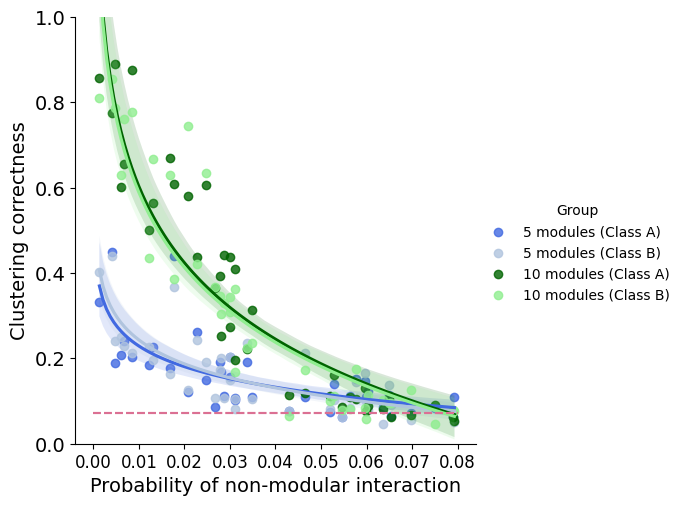

In [352]:
# Code for generating figure of bipartite clustering correctness of a modular, mutualistic network. Probability of intra-specific interactions will be fixed >0, probability 

nSpecies = 100
interactFactor = 1/5
pPositive = 0.5
pIntraInteract = 0.05

# params for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
group_size = int(0.5*nSpecies)
numits = 40

#Inter-group interactions will be varied from perfectly modular to imperfectly so
module_frac = [1/5,1/10]
starting_density = [0.5, 1]
change_tot_m  = np.random.uniform(low = 0, high = 0.08, size = numits)
change_mod = np.zeros(shape = (len(module_frac), len(change_tot_m )))

#clustering correctness stored here
left_cluster_m = np.zeros(shape = (len(module_frac),numits))
right_cluster_m = np.zeros(shape = (len(module_frac),numits))

for k in range(len(module_frac)):
    print(k)
    #for setup
    modulefrac = module_frac[k]
    mod_size = modulefrac*group_size
    num_mod = group_size/mod_size
    edge_tot = (group_size)**2
    edge_mod = num_mod*((mod_size)**2)

    change_mod[k] = ((edge_tot - edge_mod)/edge_mod)*change_tot_m

    for j in range(len(change_tot_m)):
        #Inter-group interactions will be varied from perfectly modular to imperfectly so
        pInterInteract = starting_density[k]-change_mod[k,j]
        pInterInteract_off = change_tot_m[j]

        b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
        mod_mutual = metaCommunityMx.getModularMutual(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive, modulefrac)

        #get the biadjacency matrix (1s and 0s)
        lower_only = (abs(mod_mutual[group_size:nSpecies, 0:group_size])> 0).astype(int)

        #convert to sparse matrix to get the graph for use in clustering algorithm
        B = sparse.csr_matrix(lower_only)
        G = nx.algorithms.bipartite.from_biadjacency_matrix(B)
        coms = algorithms.condor(G)

        #run GLV simulation, get cooccurrence matrix
        network_coocc_mod, G_nest_mod = run_cooccurrence.get_coocc_network(interactionMx = mod_mutual, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 100)
        modonly_cooc = (abs((network_coocc_mod[group_size:nSpecies, 0:group_size]))> 0).astype(int)

        B_cooc = sparse.csr_matrix(modonly_cooc)
        G_cooc = nx.algorithms.bipartite.from_biadjacency_matrix(B_cooc)
        coms_cooc = algorithms.condor(G_cooc)

        left_cluster_m[k,j] = metrics_and_plotting.test_bipartite_cluster_similarity_posonly(coms.left_communities, coms_cooc.left_communities)[-1]
        right_cluster_m[k,j] = metrics_and_plotting.test_bipartite_cluster_similarity_posonly(coms.right_communities, coms_cooc.right_communities)[-1]


df = pd.DataFrame(change_tot_m, columns=['xvals'])
df['5 modules (Class A)'] = left_cluster_m[0]
df['5 modules (Class B)'] = right_cluster_m[0]
df['10 modules (Class A)'] = left_cluster_m[1]
df['10 modules (Class B)'] = right_cluster_m[1]
dfl = pd.melt(df, ['xvals'])
dfl.rename(columns={'variable': 'Group'}, inplace=True)

sns.lmplot(dfl, x='xvals', y='value', hue = 'Group', palette ={"5 modules (Class A)": "royalblue", "5 modules (Class B)": "lightsteelblue", "10 modules (Class A)": "darkgreen", "10 modules (Class B)":"lightgreen"}, logx=True)
plt.ylim(0,1)
#plot average clustering correctness of random matrix 
plt.hlines(y=0.072123, xmin=0, xmax=0.08, color='palevioletred', label='Random expectation', linestyle = '--')

plt.xlabel('Probability of non-modular interaction',fontsize=14)
plt.ylabel('Clustering correctness', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.hlines(y=0.072123, xmin=0, xmax=0.08, color='palevioletred', label='Random expectation', linestyle = '--')



In [ ]:
# FINALIZED Code for generating figure of bipartite clustering correctness (TRUE POSITIVES AND TRUE NEG) of a modular, mutualistic network. 

nSpecies = 100
interactFactor = 1/5
pPositive = 0.5
pIntraInteract = 0.05

# params for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
group_size = int(0.5*nSpecies)
numits = 40

#Inter-group interactions will be varied from perfectly modular to imperfectly so
module_frac = [1/5,1/10]
starting_density = [0.5, 1]
change_tot_m  = np.random.uniform(low = 0, high = 0.08, size = numits)
change_mod = np.zeros(shape = (len(module_frac), len(change_tot_m )))

#clustering correctness stored here
left_cluster_m = np.zeros(shape = (len(module_frac),numits))
right_cluster_m = np.zeros(shape = (len(module_frac),numits))

for k in range(len(module_frac)):
    print(k)
    #for setup
    modulefrac = module_frac[k]
    mod_size = modulefrac*group_size
    num_mod = group_size/mod_size
    edge_tot = (group_size)**2
    edge_mod = num_mod*((mod_size)**2)

    change_mod[k] = ((edge_tot - edge_mod)/edge_mod)*change_tot_m

    for j in range(len(change_tot_m)):
        #Inter-group interactions will be varied from perfectly modular to imperfectly so
        pInterInteract = starting_density[k]-change_mod[k,j]
        pInterInteract_off = change_tot_m[j]

        mod_mutual = metaCommunityMx.getModularMutual(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive, modulefrac)

        #get the biadjacency matrix (1s and 0s)
        lower_only = (abs(mod_mutual[group_size:nSpecies, 0:group_size])> 0).astype(int)

        #convert to sparse matrix to get the graph for use in clustering algorithm
        B = sparse.csr_matrix(lower_only)
        G = nx.algorithms.bipartite.from_biadjacency_matrix(B)
        coms = algorithms.condor(G)

        #run GLV simulation, get cooccurrence matrix
        network_coocc_mod, G_nest_mod = run_cooccurrence.get_coocc_network(interactionMx = mod_mutual, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 100)
        modonly_cooc = (abs((network_coocc_mod[group_size:nSpecies, 0:group_size]))> 0).astype(int)

        B_cooc = sparse.csr_matrix(modonly_cooc)
        G_cooc = nx.algorithms.bipartite.from_biadjacency_matrix(B_cooc)
        coms_cooc = algorithms.condor(G_cooc)

        left_cluster_m[k,j] = metrics_and_plotting.test_bipartite_cluster_similarity(coms.left_communities, coms_cooc.left_communities)[-1]
        right_cluster_m[k,j] = metrics_and_plotting.test_bipartite_cluster_similarity(coms.right_communities, coms_cooc.right_communities)[-1]


df = pd.DataFrame(change_tot_m, columns=['xvals'])
df['5 modules (Class A)'] = left_cluster_m[0]
df['5 modules (Class B)'] = right_cluster_m[0]
df['10 modules (Class A)'] = left_cluster_m[1]
df['10 modules (Class B)'] = right_cluster_m[1]
dfl = pd.melt(df, ['xvals'])
dfl.rename(columns={'variable': 'Group'}, inplace=True)

sns.lmplot(dfl, x='xvals', y='value', hue = 'Group', palette ={"5 modules (Class A)": "royalblue", "5 modules (Class B)": "lightsteelblue", "10 modules (Class A)": "darkgreen", "10 modules (Class B)":"lightgreen"}, logx=True)
plt.ylim(0,1)
#plot average clustering correctness of random matrix 
plt.hlines(y=0.65099, xmin=0, xmax=0.08, color='palevioletred', label='Random expectation', linestyle = '--')

plt.xlabel('Probability of non-modular interaction',fontsize=14)
plt.ylabel('Clustering correctness', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)




(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0')])

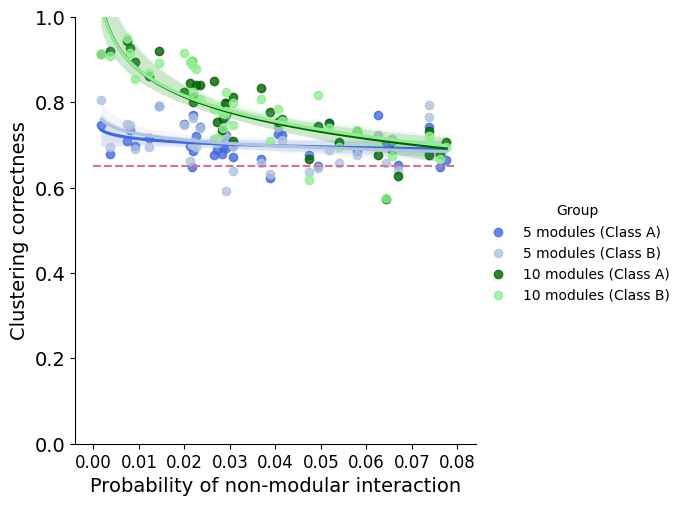

In [354]:
sns.lmplot(dfl, x='xvals', y='value', hue = 'Group', palette ={"5 modules (Class A)": "royalblue", "5 modules (Class B)": "lightsteelblue", "10 modules (Class A)": "darkgreen", "10 modules (Class B)":"lightgreen"}, logx=True)
plt.ylim(0,1)
#plot average clustering correctness of random matrix 
plt.hlines(y=0.65099, xmin=0, xmax=0.08, color='palevioletred', label='Random expectation', linestyle = '--')

plt.xlabel('Probability of non-modular interaction',fontsize=14)
plt.ylabel('Clustering correctness', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)

0
1


(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0')])

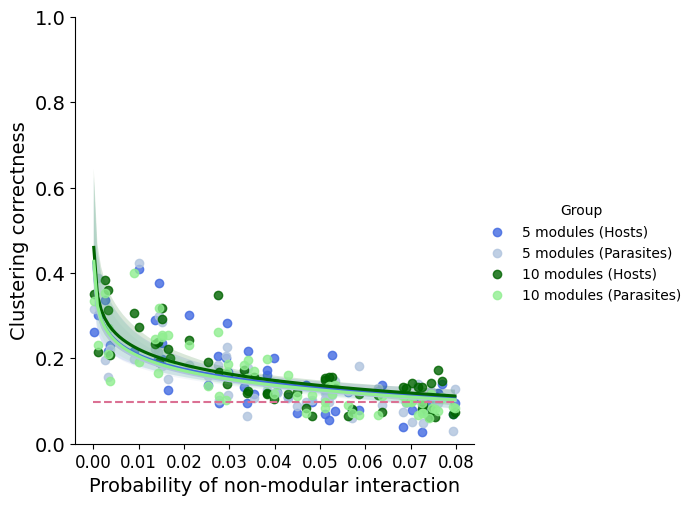

In [355]:
# FINALIZED Code for generating figure of bipartite clustering correctness (TRUE POSITIVES ONLY) of a modular host-parasite network. 

nSpecies = 100
interactFactor = 1/5
pPositive = 0.5
pIntraInteract = 0.05

# params for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
group_size = int(0.5*nSpecies)
numits = 60

#Inter-group interactions will be varied from perfectly modular to imperfectly so
module_frac = [1/5,1/10]
starting_density = [0.5, 1]
change_tot_m  = np.random.uniform(low = 0, high = 0.08, size = numits)
change_mod = np.zeros(shape = (len(module_frac), len(change_tot_m )))

#clustering correctness stored here
left_cluster_m = np.zeros(shape = (len(module_frac),numits))
right_cluster_m = np.zeros(shape = (len(module_frac),numits))

for k in range(len(module_frac)):
    print(k)
    #for setup
    modulefrac = module_frac[k]
    mod_size = modulefrac*group_size
    num_mod = group_size/mod_size
    edge_tot = (group_size)**2
    edge_mod = num_mod*((mod_size)**2)

    change_mod[k] = ((edge_tot - edge_mod)/edge_mod)*change_tot_m

    for j in range(len(change_tot_m)):
        #Inter-group interactions will be varied from perfectly modular to imperfectly so
        pInterInteract = starting_density[k]-change_mod[k,j]
        pInterInteract_off = change_tot_m[j]

        mod_parasite = metaCommunityMx.getModularParasite(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive, modulefrac)

        #get the biadjacency matrix (1s and 0s)
        lower_only = (abs(mod_parasite[group_size:nSpecies, 0:group_size])> 0).astype(int)

        #convert to sparse matrix to get the graph for use in clustering algorithm
        B = sparse.csr_matrix(lower_only)
        G = nx.algorithms.bipartite.from_biadjacency_matrix(B)
        coms = algorithms.condor(G)

        #run GLV simulation, get cooccurrence matrix
        network_coocc_mod, G_nest_mod = run_cooccurrence.get_coocc_network(interactionMx = mod_parasite, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 100)
        modonly_cooc = (abs((network_coocc_mod[group_size:nSpecies, 0:group_size]))> 0).astype(int)

        B_cooc = sparse.csr_matrix(modonly_cooc)
        G_cooc = nx.algorithms.bipartite.from_biadjacency_matrix(B_cooc)
        coms_cooc = algorithms.condor(G_cooc)

        left_cluster_m[k,j] = metrics_and_plotting.test_bipartite_cluster_similarity_posonly(coms.left_communities, coms_cooc.left_communities)[-1]
        right_cluster_m[k,j] = metrics_and_plotting.test_bipartite_cluster_similarity_posonly(coms.right_communities, coms_cooc.right_communities)[-1]



df = pd.DataFrame(change_tot_m, columns=['xvals'])
df['5 modules (Hosts)'] = left_cluster_m[0]
df['5 modules (Parasites)'] = right_cluster_m[0]
df['10 modules (Hosts)'] = left_cluster_m[1]
df['10 modules (Parasites)'] = right_cluster_m[1]
dfl = pd.melt(df, ['xvals'])
dfl.rename(columns={'variable': 'Group'}, inplace=True)

sns.lmplot(dfl, x='xvals', y='value', hue = 'Group', palette ={"5 modules (Hosts)": "royalblue", "5 modules (Parasites)": "lightsteelblue", "10 modules (Hosts)": "darkgreen", "10 modules (Parasites)":"lightgreen"}, logx=True)
plt.ylim(0,1)
#plot average clustering correctness of random matrix 
plt.hlines(y=0.098256, xmin=0, xmax=0.08, color='palevioletred', label='Random expectation', linestyle = '--')
plt.xlabel('Probability of non-modular interaction',fontsize=14)
plt.ylabel('Clustering correctness', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)




In [ ]:
# Code for generating figure of bipartite clustering correctness (TRUE POSITIVES AND TRUE NEGATIVES) of a modular host-parasite network. 

nSpecies = 100
interactFactor = 1/5
pPositive = 0.5
pIntraInteract = 0.05

# params for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
group_size = int(0.5*nSpecies)
numits = 60

#Inter-group interactions will be varied from perfectly modular to imperfectly so
module_frac = [1/5,1/10]
starting_density = [0.5, 1]
change_tot_m  = np.random.uniform(low = 0, high = 0.08, size = numits)
change_mod = np.zeros(shape = (len(module_frac), len(change_tot_m )))

#clustering correctness stored here
left_cluster_m = np.zeros(shape = (len(module_frac),numits))
right_cluster_m = np.zeros(shape = (len(module_frac),numits))

for k in range(len(module_frac)):
    print(k)
    #for setup
    modulefrac = module_frac[k]
    mod_size = modulefrac*group_size
    num_mod = group_size/mod_size
    edge_tot = (group_size)**2
    edge_mod = num_mod*((mod_size)**2)

    change_mod[k] = ((edge_tot - edge_mod)/edge_mod)*change_tot_m

    for j in range(len(change_tot_m)):
        #Inter-group interactions will be varied from perfectly modular to imperfectly so
        pInterInteract = starting_density[k]-change_mod[k,j]
        pInterInteract_off = change_tot_m[j]

        mod_parasite = metaCommunityMx.getModularParasite(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive, modulefrac)

        #get the biadjacency matrix (1s and 0s)
        lower_only = (abs(mod_parasite[group_size:nSpecies, 0:group_size])> 0).astype(int)

        #convert to sparse matrix to get the graph for use in clustering algorithm
        B = sparse.csr_matrix(lower_only)
        G = nx.algorithms.bipartite.from_biadjacency_matrix(B)
        coms = algorithms.condor(G)

        #run GLV simulation, get cooccurrence matrix
        network_coocc_mod, G_nest_mod = run_cooccurrence.get_coocc_network(interactionMx = mod_parasite, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 100)
        modonly_cooc = (abs((network_coocc_mod[group_size:nSpecies, 0:group_size]))> 0).astype(int)

        B_cooc = sparse.csr_matrix(modonly_cooc)
        G_cooc = nx.algorithms.bipartite.from_biadjacency_matrix(B_cooc)
        coms_cooc = algorithms.condor(G_cooc)

        left_cluster_m[k,j] = metrics_and_plotting.test_bipartite_cluster_similarity(coms.left_communities, coms_cooc.left_communities)[-1]
        right_cluster_m[k,j] = metrics_and_plotting.test_bipartite_cluster_similarity(coms.right_communities, coms_cooc.right_communities)[-1]


df = pd.DataFrame(change_tot_m, columns=['xvals'])
df['5 modules (Hosts)'] = left_cluster_m[0]
df['5 modules (Parasites)'] = right_cluster_m[0]
df['10 modules (Hosts)'] = left_cluster_m[1]
df['10 modules (Parasites)'] = right_cluster_m[1]
dfl = pd.melt(df, ['xvals'])
dfl.rename(columns={'variable': 'Group'}, inplace=True)

sns.lmplot(dfl, x='xvals', y='value', hue = 'Group', palette ={"5 modules (Hosts)": "royalblue", "5 modules (Parasites)": "lightsteelblue", "10 modules (Hosts)": "darkgreen", "10 modules (Parasites)":"lightgreen"},logx=True)
plt.ylim(0,1)
#plot average clustering correctness of random matrix 
plt.hlines(y=0.7141801, xmin=0, xmax=0.08, color='palevioletred', label='Random expectation', linestyle = '--')
plt.ylabel('Clustering correctness', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)


In [ ]:
#Random matrix expectations of clustering correctness - use ModularMutual or ModularParasite

nSpecies = 100
interactFactor = 1/5
pPositive = 0.5
pIntraInteract = 0.05

# params for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
group_size = int(0.5*nSpecies)
numits = 20

#Inter-group interactions will be varied from perfectly modular to imperfectly so
module_frac = [1]
change_tot = np.random.uniform(low = 0, high = 0.1, size = numits)

#clustering correctness stored here
left_cluster = np.zeros(shape = (len(module_frac),numits))
right_cluster = np.zeros(shape = (len(module_frac),numits))

for k in range(len(module_frac)):
    print(k)
    #for setup
    modulefrac = module_frac[k]

    for j in range(len(change_tot)):
        #Inter-group interactions will be varied from perfectly modular to imperfectly so
        pInterInteract = 0.1
        pInterInteract_off = 0

        mod_parasite = metaCommunityMx.getModularMutual(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive, modulefrac)

        #get the biadjacency matrix (1s and 0s)
        lower_only = (abs(mod_parasite[group_size:nSpecies, 0:group_size])> 0).astype(int)

        #convert to sparse matrix to get the graph for use in clustering algorithm
        B = sparse.csr_matrix(lower_only)
        G = nx.algorithms.bipartite.from_biadjacency_matrix(B)
        coms = algorithms.condor(G)

        #run GLV simulation, get cooccurrence matrix
        network_coocc_mod, G_nest_mod = run_cooccurrence.get_coocc_network(interactionMx = mod_parasite, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 100)
        modonly_cooc = (abs((network_coocc_mod[group_size:nSpecies, 0:group_size]))> 0).astype(int)

        B_cooc = sparse.csr_matrix(modonly_cooc)
        G_cooc = nx.algorithms.bipartite.from_biadjacency_matrix(B_cooc)
        coms_cooc = algorithms.condor(G_cooc)

        left_cluster[k,j] = metrics_and_plotting.test_bipartite_cluster_similarity(coms.left_communities, coms_cooc.left_communities)[-1]
        right_cluster[k,j] = metrics_and_plotting.test_bipartite_cluster_similarity(coms.right_communities, coms_cooc.right_communities)[-1]


print(np.average(left_cluster[0]))


In [ ]:
#ALL HELPER FUNCTIONS FOR SIGNIFICANT STRUCTURE SIMULATIONS

def nodf_barberq_intervals(network, group_size):

    nestednull = np.zeros(1000)
    for i in range(len(nestednull)):
        shuffled = network.copy()
        shuffled = shuffled.flatten()
        np.random.shuffle(shuffled)
        shuffled = shuffled.reshape(group_size,group_size)
        
        nodf_shuffle = metrics_and_plotting.calculate_nodf(shuffled)
        nestednull[i]=nodf_shuffle

        B_shuff = sparse.csr_matrix(shuffled)
        G_shuff = nx.algorithms.bipartite.from_biadjacency_matrix(B_shuff)
        coms_shuff = algorithms.condor(G_shuff)
        barberq_shuffle = metrics_and_plotting.calculate_barber_modularity_bipartite(shuffled, coms_shuff.left_communities, coms_shuff.right_communities, group_size)
        modnull[i]=barberq_shuffle

    
    low_nodf = np.percentile(nestednull, 2.5)
    high_nodf = np.percentile(nestednull, 97.5)

    low_barber = np.percentile(modnull, 2.5)
    high_barber = np.percentile(modnull, 97.5)


    return low_nodf, high_nodf, low_barber, high_barber



def nodf_interval(network): 

    nestednull = np.zeros(1000)
    for i in range(len(nestednull)):
        shufflednest = network.copy()
        np.random.shuffle(shufflednest)
        for sublist in shufflednest:
            np.random.shuffle(sublist)
    
        shuffle2 = shufflednest.transpose()
        for sublist in shuffle2:
            np.random.shuffle(sublist)
        np.random.shuffle(shuffle2)
        
        nodf_shuffle = metrics_and_plotting.calculate_nodf(shuffle2)
        nestednull[i]=nodf_shuffle

        

    low = np.percentile(nestednull, 2.5)
    high = np.percentile(nestednull, 97.5)
    return low, high

def barberfrom_matrix(matrix,group_size):#needs a matrix with positive entries

    B = sparse.csr_matrix(matrix)
    G = nx.algorithms.bipartite.from_biadjacency_matrix(B)
    coms = algorithms.condor(G)
    #print(coms.left_communities)
    #print(coms.right_communities)
    barbermod = metrics_and_plotting.calculate_barber_modularity_bipartite(matrix, coms.left_communities, coms.right_communities, group_size)
    return barbermod


def barberq_interval(network, group_size):#needs an unweighted, unsigned network (i.e. 0s and 1s)
    
    modnull = np.zeros(1000)
    for i in range(len(modnull)):
        shuffledmod = network.copy()
        np.random.shuffle(shuffledmod)
        for sublist in shuffledmod:
            np.random.shuffle(sublist)

        shuffle2 = shuffledmod.transpose()
        for sublist in shuffle2:
            np.random.shuffle(sublist)
        np.random.shuffle(shuffle2)

        B_shuff = sparse.csr_matrix(shuffle2)
        G_shuff = nx.algorithms.bipartite.from_biadjacency_matrix(B_shuff)
        coms_shuff = algorithms.condor(G_shuff)
        barberq_shuffle = metrics_and_plotting.calculate_barber_modularity_bipartite(shuffle2, coms_shuff.left_communities, coms_shuff.right_communities, group_size)
        modnull[i]=barberq_shuffle

    low = np.percentile(modnull, 2.5)
    high = np.percentile(modnull, 97.5)
    return low, high


def threshold_sigstructure(xdata, ydata, upper_bound):
    y_binary = np.zeros(len(ydata))

    for i in range(len(ydata)):
        if ydata[i] > upper_bound[i]:
            y_binary[i] = 1

    xdata = sm.add_constant(xdata)
    log_fit = sm.GLM(y_binary, xdata, family=sm.families.Binomial()).fit()
    threshold = -log_fit.params[0]/log_fit.params[1]
    if threshold < 0:
        threshold = 0
    return log_fit, threshold

def plot_interval(x, ymin, ymax, color='lightgrey'):
    plt.vlines(x, ymin, ymax, color, lw=1)
    plt.hlines(ymin, x+0.001, x-0.001, color, lw=1)
    plt.hlines(ymax, x+0.001, x-0.001, color, lw=1)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -5.5594
Date:                Thu, 12 Feb 2026   Deviance:                       11.119
Time:                        11:55:55   Pearson chi2:                     11.7
No. Iterations:                    11   Pseudo R-squ. (CS):             0.3898

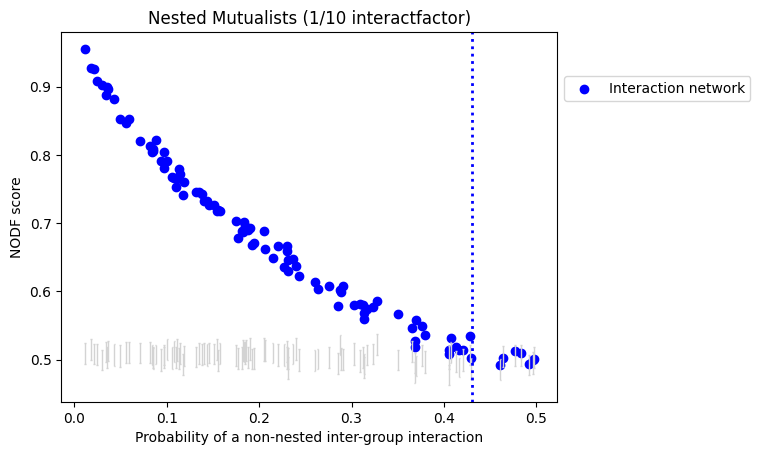

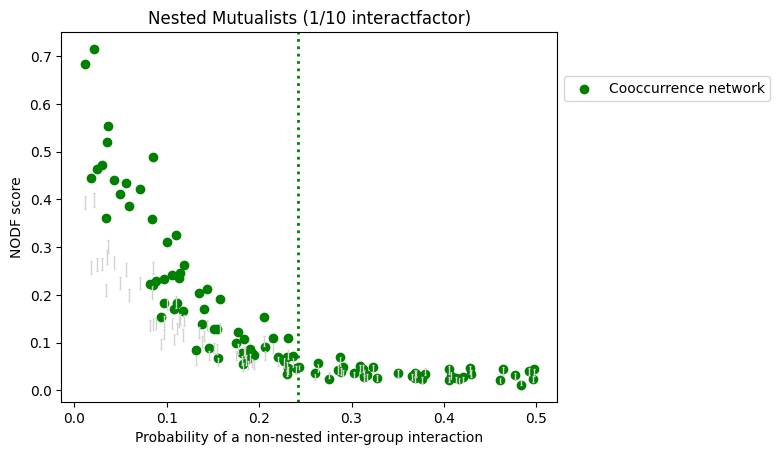

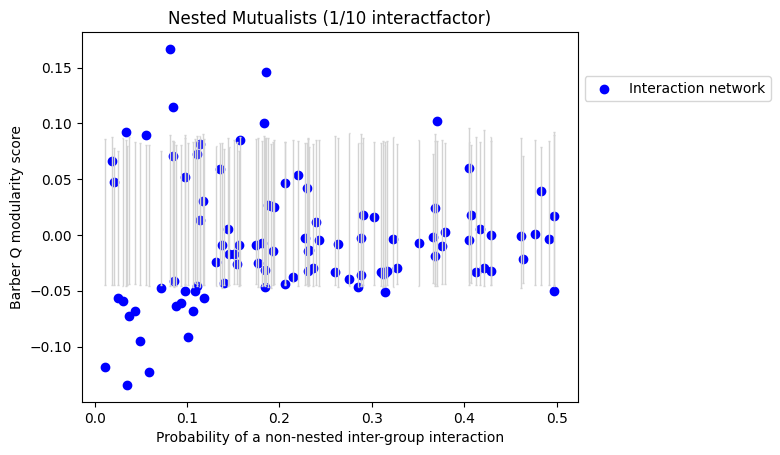

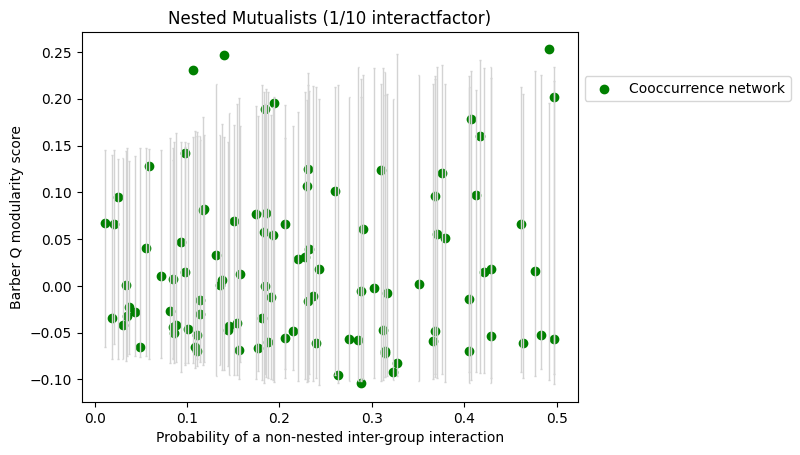

In [215]:
#Code to classify MUTUALISTIC networks as significantly modular, significantly nested, or neither. 
#Things to run: nested, 2 modules, 5 modules, 10 modules, and random -- all with varying percentages of off-structure inter-group interactions (excl. random)
#For each iteration: generate interaction network. Calculate NODF/Barber Q, generate confidence intervals, determin if sig. nested or modular. 
# Run GLV simulation, generate cooccurrence network. Generate confidence intervals for both NODF and Barber Q, determine if sig. nested or modular.
#IntraInteract is set at 0.1 instead of 0.05 so pPositive can remain the same without blowups. 


numits = 100
displacements = np.random.uniform(low=0.01, high=0.5, size=numits)

nodf_int_vec_nestmutual = np.zeros((len(displacements)))
nodf_int_low_nestmutual = np.zeros((len(displacements)))
nodf_int_high_nestmutual = np.zeros((len(displacements)))

barber_int_vec_nestmutual = np.zeros((len(displacements)))
barber_int_low_nestmutual = np.zeros((len(displacements)))
barber_int_high_nestmutual = np.zeros((len(displacements)))

nodf_cooc_vec_nestmutual = np.zeros((len(displacements)))
nodf_cooc_low_nestmutual = np.zeros((len(displacements)))
nodf_cooc_high_nestmutual = np.zeros((len(displacements)))

barber_cooc_vec_nestmutual = np.zeros((len(displacements)))
barber_cooc_low_nestmutual = np.zeros((len(displacements)))
barber_cooc_high_nestmutual = np.zeros((len(displacements)))

#params for all simulations

nSpecies = 100
interactFactor = 1/10
pPositive = 0.2
pIntraInteract = 0.1

# params for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
group_size = int(0.5*nSpecies)

##CODE FOR NESTED MUTUALISTIC NETWORK

for i in range(len(displacements)):

    print(i)
    pInterInteract = 1-displacements[i]
    pInterInteract_off = displacements[i]
    
    nestedmutual = metaCommunityMx.getNestedMutual(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive)
    #BELOW IS ALWAYS POSITIVE
    nestedonly_int = nestedmutual[0:group_size, group_size:nSpecies]

    #check if interaction network is significantly nested/modular
    nodf_int_vec_nestmutual[i] = metrics_and_plotting.calculate_nodf(nestedonly_int)
    barber_int_vec_nestmutual[i] = barberfrom_matrix(nestedonly_int,group_size)
    nodf_int_low_nestmutual[i], nodf_int_high_nestmutual[i], barber_int_low_nestmutual[i], barber_int_high_nestmutual[i] = nodf_barberq_intervals(nestedonly_int, group_size)
    
    #Get co-occurrence network, make similar calculations
    network_cooccnest, G_nest_coocc = run_cooccurrence.get_coocc_network(interactionMx = nestedmutual, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 150)
    nestedonly_cooc = (abs(network_cooccnest[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if cooccurrence network is significantly nested
    nodf_cooc_vec_nestmutual[i] = metrics_and_plotting.calculate_nodf(nestedonly_cooc)
    barber_cooc_vec_nestmutual[i] = barberfrom_matrix(nestedonly_cooc,group_size)
    nodf_cooc_low_nestmutual[i], nodf_cooc_high_nestmutual[i], barber_cooc_low_nestmutual[i], barber_cooc_high_nestmutual[i] = nodf_barberq_intervals(nestedonly_cooc, group_size)


interact_fitted_nestedmutual, interaction_threshold_nestmutual = threshold_sigstructure(displacements, nodf_int_vec_nestmutual, nodf_int_high_nestmutual)
cooc_fitted_nestedmutual, cooc_threshold_nestmutual = threshold_sigstructure(displacements, nodf_cooc_vec_nestmutual, nodf_cooc_high_nestmutual)

print(interact_fitted_nestedmutual.summary())
print(cooc_fitted_nestedmutual.summary())

plt.scatter(displacements, nodf_int_vec_nestmutual, color = 'b', label = 'Interaction network')
plot_interval(displacements, nodf_int_low_nestmutual, nodf_int_high_nestmutual)
plt.axvline(x=interaction_threshold_nestmutual, color='b', linestyle='dotted', linewidth=2)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-nested inter-group interaction')
plt.title('Nested Mutualists (1/10 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, nodf_cooc_vec_nestmutual, color='g', label = 'Cooccurrence network')
plot_interval(displacements, nodf_cooc_low_nestmutual, nodf_cooc_high_nestmutual)
plt.axvline(x=cooc_threshold_nestmutual, color='g', linestyle='dotted', linewidth=2)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-nested inter-group interaction')
plt.title('Nested Mutualists (1/10 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_int_vec_nestmutual, color = 'b', label = 'Interaction network')
plot_interval(displacements, barber_int_low_nestmutual, barber_int_high_nestmutual)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-nested inter-group interaction')
plt.title('Nested Mutualists (1/10 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_cooc_vec_nestmutual, color='g', label = 'Cooccurrence network')
plot_interval(displacements, barber_cooc_low_nestmutual, barber_cooc_high_nestmutual)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-nested inter-group interaction')
plt.title('Nested Mutualists (1/10 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()



In [ ]:
#Code to classify NESTED PARASITE networks as significantly modular, significantly nested, or neither. 
#uses functions from NESTED MUTUALISTIC, make sure to run first. 

numits = 100
displacements = np.random.uniform(low=0.01, high = 0.5, size=numits)

nodf_int_vec_nestedparasite = np.zeros((len(displacements)))
nodf_int_low_nestedparasite = np.zeros((len(displacements)))
nodf_int_high_nestedparasite = np.zeros((len(displacements)))

barber_int_vec_nestedparasite = np.zeros((len(displacements)))
barber_int_low_nestedparasite = np.zeros((len(displacements)))
barber_int_high_nestedparasite = np.zeros((len(displacements)))

nodf_cooc_vec_nestedparasite = np.zeros((len(displacements)))
nodf_cooc_low_nestedparasite = np.zeros((len(displacements)))
nodf_cooc_high_nestedparasite = np.zeros((len(displacements)))

barber_cooc_vec_nestedparasite = np.zeros((len(displacements)))
barber_cooc_low_nestedparasite = np.zeros((len(displacements)))
barber_cooc_high_nestedparasite = np.zeros((len(displacements)))


#params for all simulations

nSpecies = 100
interactFactor = 1/10
pPositive = 0.2
pIntraInteract = 0.1

# params for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
group_size = int(0.5*nSpecies)


##CODE FOR NESTED PARASITE NETWORK

for i in range(len(displacements)):

    print(i)
    pInterInteract = 1-displacements[i]
    pInterInteract_off = displacements[i]
    
    nestedparasite = metaCommunityMx.getNestedParasite(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive)
    nestedonly_int = (abs(nestedparasite[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if interaction network is significantly nested
    nodf_int_vec_nestedparasite[i] = metrics_and_plotting.calculate_nodf(nestedonly_int)
    barber_int_vec_nestedparasite[i] = barberfrom_matrix(nestedonly_int,group_size)
    nodf_int_low_nestedparasite[i], nodf_int_high_nestedparasite[i],barber_int_low_nestedparasite[i], barber_int_high_nestedparasite[i] = nodf_barberq_intervals(nestedonly_int, group_size)
    
    #Get co-occurrence network, make similar calculations
    network_cooccnest, G_nest_coocc = run_cooccurrence.get_coocc_network(interactionMx = nestedparasite, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 150)
    nestedonly_cooc = (abs(network_cooccnest[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if cooccurrence network is significantly nested
    nodf_cooc_vec_nestedparasite[i] = metrics_and_plotting.calculate_nodf(nestedonly_cooc)
    barber_cooc_vec_nestedparasite[i] = barberfrom_matrix(nestedonly_cooc,group_size)
    nodf_cooc_low_nestedparasite[i], nodf_cooc_high_nestedparasite[i], barber_cooc_low_nestedparasite[i], barber_cooc_high_nestedparasite[i]= nodf_barberq_intervals(nestedonly_cooc, group_size)


interact_fitted_nestedparasite, interaction_threshold_nestpar = threshold_sigstructure(displacements, nodf_int_vec_nestedparasite, nodf_int_high_nestedparasite)
cooc_fitted_nestedparasite, cooc_threshold_nestpar = threshold_sigstructure(displacements, nodf_cooc_vec_nestedparasite, nodf_cooc_high_nestedparasite)

plt.scatter(displacements, nodf_int_vec_nestedparasite, color = 'b', label = 'Interaction network')
plot_interval(displacements, nodf_int_low_nestedparasite, nodf_int_high_nestedparasite)
plt.axvline(x=interaction_threshold_nestpar, color='b', linestyle='dotted', linewidth=2)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-nested inter-group interaction')
plt.title('Nested Parasites (1/10 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, nodf_cooc_vec_nestedparasite, color='g', label = 'Cooccurrence network')
plot_interval(displacements, nodf_cooc_low_nestedparasite, nodf_cooc_high_nestedparasite)
plt.axvline(x=cooc_threshold_nestpar, color='g', linestyle='dotted', linewidth=2)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-nested inter-group interaction')
plt.title('Nested Parasites (1/10 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_int_vec_nestedparasite, color = 'b', label = 'Interaction network')
plot_interval(displacements, barber_int_low_nestedparasite, barber_int_high_nestedparasite)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-nested inter-group interaction')
plt.title('Nested Parasites (1/10 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_cooc_vec_nestedparasite, color='g', label = 'Cooccurrence network')
plot_interval(displacements, barber_cooc_low_nestedparasite, barber_cooc_high_nestedparasite)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-nested inter-group interaction')
plt.title('Nested Parasites (1/10 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()




0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


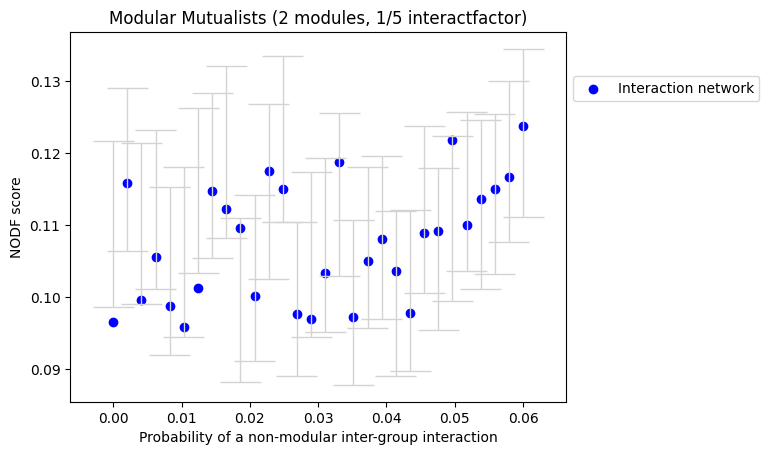

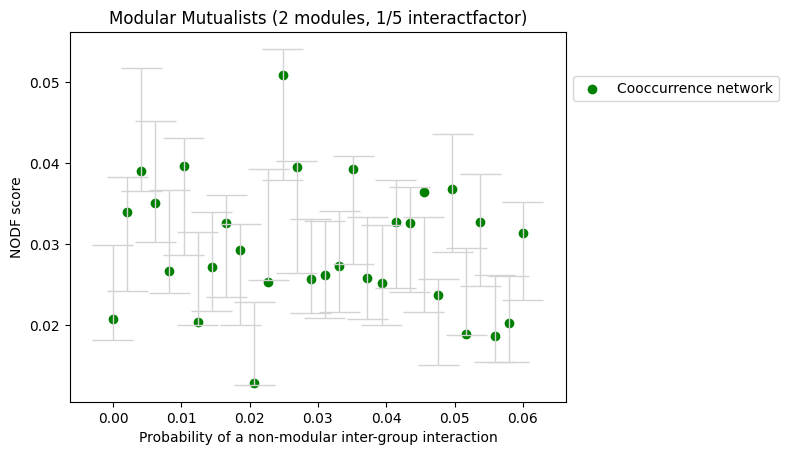

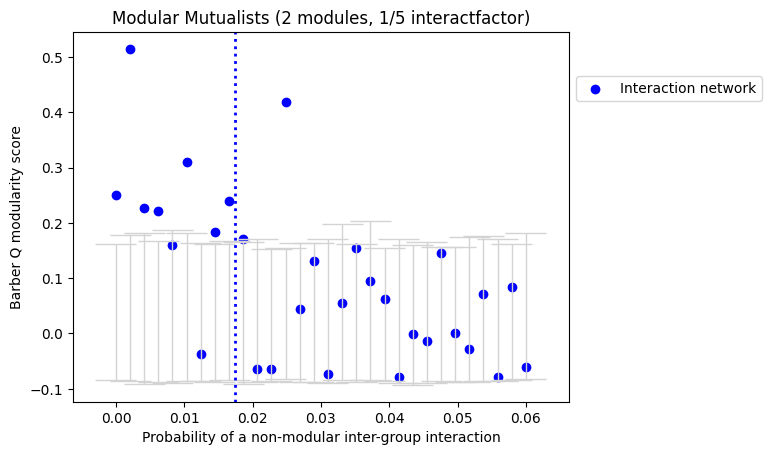

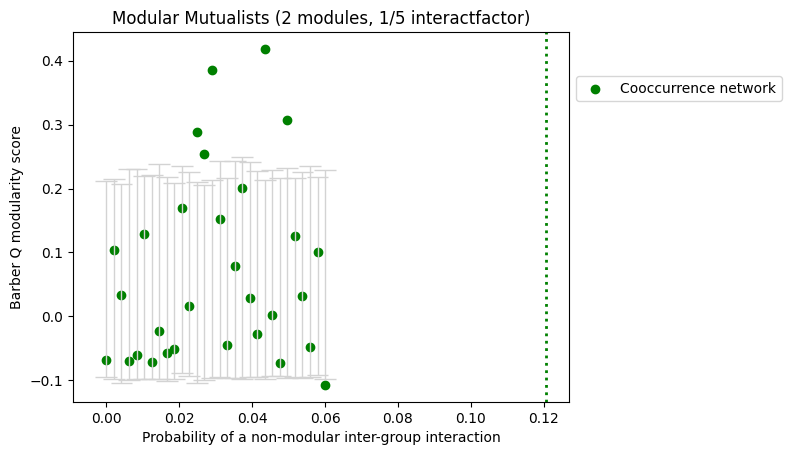

In [51]:
#Code to classify MODULAR MUTUALIST networks (2 modules) as significantly modular, significantly nested, or neither. 
#uses functions from NESTED MUTUALISTIC, make sure to run first. 

numits = 30
displacements = np.linspace(0, 0.06, num=numits)

nodf_int_vec_2modmutual = np.zeros((len(displacements)))
nodf_int_low_2modmutual = np.zeros((len(displacements)))
nodf_int_high_2modmutual = np.zeros((len(displacements)))

barber_int_vec_2modmutual = np.zeros((len(displacements)))
barber_int_low_2modmutual = np.zeros((len(displacements)))
barber_int_high_2modmutual = np.zeros((len(displacements)))

nodf_cooc_vec_2modmutual = np.zeros((len(displacements)))
nodf_cooc_low_2modmutual = np.zeros((len(displacements)))
nodf_cooc_high_2modmutual = np.zeros((len(displacements)))

barber_cooc_vec_2modmutual = np.zeros((len(displacements)))
barber_cooc_low_2modmutual = np.zeros((len(displacements)))
barber_cooc_high_2modmutual = np.zeros((len(displacements)))


#params for all simulations

nSpecies = 100
interactFactor = 1/5
pPositive = 0.5
pIntraInteract = 0.05

# params for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
group_size = int(0.5*nSpecies)
modulefrac = 1/2

mod_size = modulefrac*group_size
num_mod = group_size/mod_size
edge_tot = (group_size)**2
edge_mod = num_mod*((mod_size)**2)


for i in range(len(displacements)):

    print(i)
    change_mod = ((edge_tot - edge_mod)/edge_mod)*displacements[i]

    pInterInteract = 0.2-change_mod
    pInterInteract_off = displacements[i]
    
    mod_mutual = metaCommunityMx.getModularMutual(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive, modulefrac)
    modonly_int = (abs(mod_mutual[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if interaction network is significantly nested
    nodf_int_vec_2modmutual[i] = metrics_and_plotting.calculate_nodf(modonly_int)
    barber_int_vec_2modmutual[i] = barberfrom_matrix(modonly_int,group_size)
    nodf_int_low_2modmutual[i], nodf_int_high_2modmutual[i],barber_int_low_2modmutual[i], barber_int_high_2modmutual[i] = nodf_barberq_intervals(modonly_int, group_size)

    #Get co-occurrence network, make similar calculations
    network_cooccmod, G_mod_coocc = run_cooccurrence.get_coocc_network(interactionMx = mod_mutual, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 150)
    modonly_cooc = (abs(network_cooccmod[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if cooccurrence network is significantly nested
    nodf_cooc_vec_2modmutual[i] = metrics_and_plotting.calculate_nodf(modonly_cooc)
    barber_cooc_vec_2modmutual[i] = barberfrom_matrix(modonly_cooc,group_size)
    nodf_cooc_low_2modmutual[i], nodf_cooc_high_2modmutual[i], barber_cooc_low_2modmutual[i], barber_cooc_high_2modmutual[i] = nodf_barberq_intervals(modonly_cooc, group_size)


interact_fitted_2modmutual, interaction_threshold = threshold_sigstructure(displacements, barber_int_vec_2modmutual, barber_int_high_2modmutual)
cooc_fitted_2modmutual, cooc_threshold = threshold_sigstructure(displacements, barber_cooc_vec_2modmutual, barber_cooc_high_2modmutual)

plt.scatter(displacements, nodf_int_vec_2modmutual, color = 'b', label = 'Interaction network')
plot_interval(displacements, nodf_int_low_2modmutual, nodf_int_high_2modmutual)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Mutualists (2 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, nodf_cooc_vec_2modmutual, color='g', label = 'Cooccurrence network')
plot_interval(displacements, nodf_cooc_low_2modmutual, nodf_cooc_high_2modmutual)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Mutualists (2 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_int_vec_2modmutual, color = 'b', label = 'Interaction network')
plot_interval(displacements, barber_int_low_2modmutual, barber_int_high_2modmutual)
plt.axvline(x=interaction_threshold, color='b', linestyle='dotted', linewidth=2)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Mutualists (2 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_cooc_vec_2modmutual, color='g', label = 'Cooccurrence network')
plot_interval(displacements, barber_cooc_low_2modmutual, barber_cooc_high_2modmutual)
plt.axvline(x=cooc_threshold, color='g', linestyle='dotted', linewidth=2)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Mutualists (2 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()


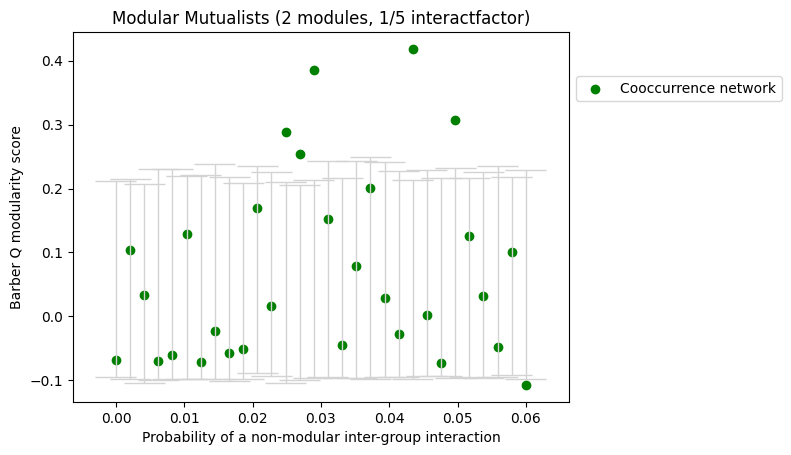

In [56]:
plt.scatter(displacements, barber_cooc_vec_2modmutual, color='g', label = 'Cooccurrence network')
plot_interval(displacements, barber_cooc_low_2modmutual, barber_cooc_high_2modmutual)
#plt.axvline(x=cooc_threshold, color='g', linestyle='dotted', linewidth=2)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Mutualists (2 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


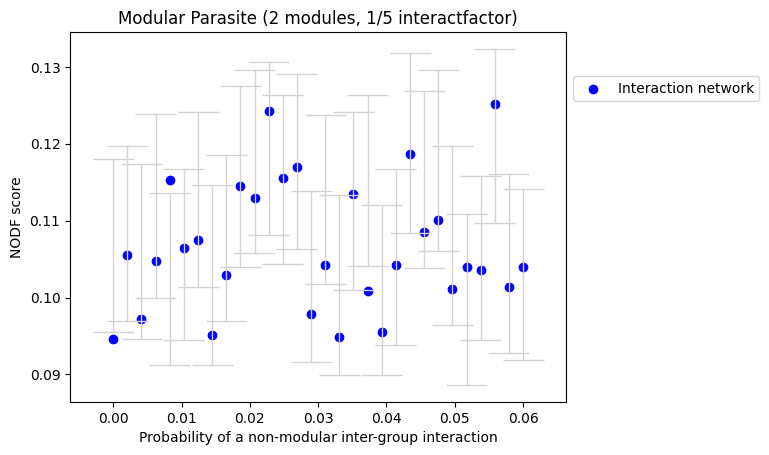

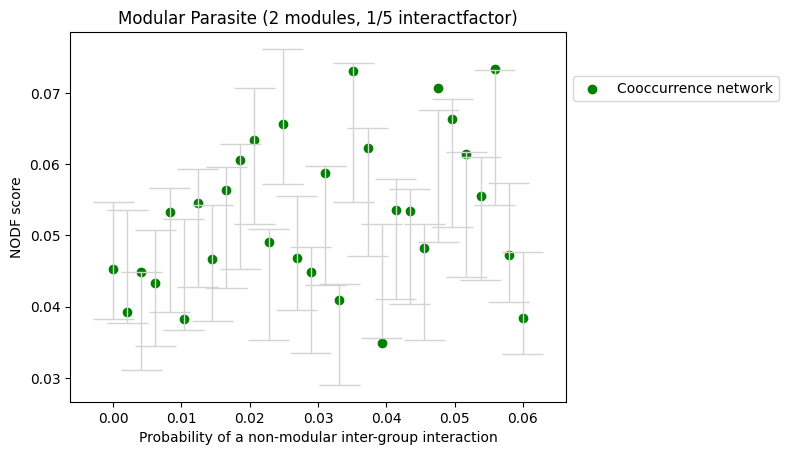

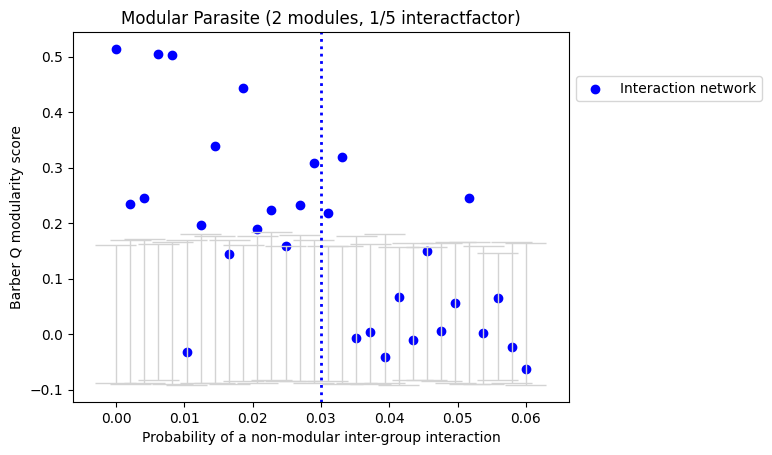

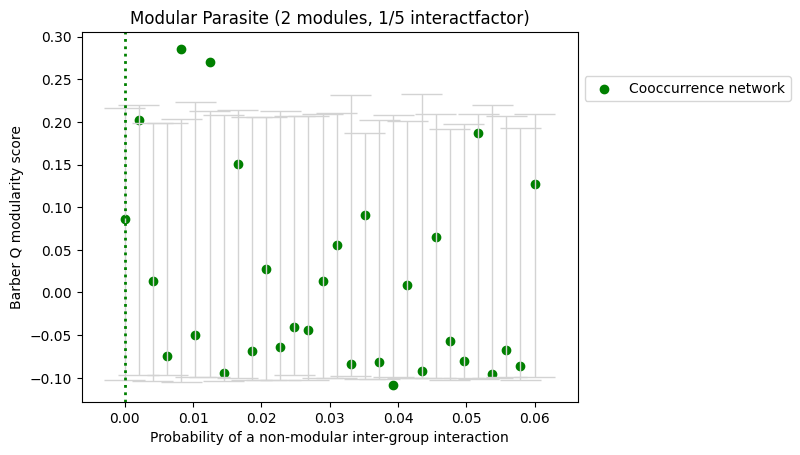

In [ ]:

#Code to classify MODULAR PARASITE networks (2 modules) as significantly modular, significantly nested, or neither. 

numits = 30
displacements = np.linspace(0, 0.06, num=numits)

nodf_int_vec_2modant = np.zeros((len(displacements)))
nodf_int_low_2modant = np.zeros((len(displacements)))
nodf_int_high_2modant = np.zeros((len(displacements)))

barber_int_vec_2modant = np.zeros((len(displacements)))
barber_int_low_2modant = np.zeros((len(displacements)))
barber_int_high_2modant = np.zeros((len(displacements)))

nodf_cooc_vec_2modant = np.zeros((len(displacements)))
nodf_cooc_low_2modant = np.zeros((len(displacements)))
nodf_cooc_high_2modant = np.zeros((len(displacements)))

barber_cooc_vec_2modant = np.zeros((len(displacements)))
barber_cooc_low_2modant = np.zeros((len(displacements)))
barber_cooc_high_2modant = np.zeros((len(displacements)))


#params for all simulations

nSpecies = 100
interactFactor = 1/5
pPositive = 0.5
pIntraInteract = 0.05

# params for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
group_size = int(0.5*nSpecies)
modulefrac = 1/2

mod_size = modulefrac*group_size
num_mod = group_size/mod_size
edge_tot = (group_size)**2
edge_mod = num_mod*((mod_size)**2)


for i in range(len(displacements)):

    print(i)
    change_mod = ((edge_tot - edge_mod)/edge_mod)*displacements[i]

    pInterInteract = 0.2-change_mod
    pInterInteract_off = displacements[i]
    
    mod_parasite = metaCommunityMx.getModularParasite(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive, modulefrac)
    #BELOW IS ALWAYS POSITIVE
    modonly_int = (abs(mod_parasite[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if interaction network is significantly nested
    nodf_int_vec_2modant[i] = metrics_and_plotting.calculate_nodf(modonly_int)
    barber_int_vec_2modant[i] = barberfrom_matrix(modonly_int,group_size)
    nodf_int_low_2modant[i], nodf_int_high_2modant[i], barber_int_low_2modant[i], barber_int_high_2modant[i] = nodf_barberq_intervals(modonly_int, group_size)
    
    #Get co-occurrence network, make similar calculations
    network_cooccmod, G_mod_coocc = run_cooccurrence.get_coocc_network(interactionMx = mod_parasite, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 150)
    modonly_cooc = (abs(network_cooccmod[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if cooccurrence network is significantly nested
    nodf_cooc_vec_2modant[i] = metrics_and_plotting.calculate_nodf(modonly_cooc)
    barber_cooc_vec_2modant[i] = barberfrom_matrix(modonly_cooc,group_size)
    nodf_cooc_low_2modant[i], nodf_cooc_high_2modant[i], barber_cooc_low_2modant[i], barber_cooc_high_2modant[i] = nodf_barberq_intervals(modonly_cooc, group_size)

    
interact_fitted_2modant, interaction_threshold_2modant = threshold_sigstructure(displacements, barber_int_vec_2modant, barber_int_high_2modant)
cooc_fitted_2modant, cooc_threshold_2modant = threshold_sigstructure(displacements, barber_cooc_vec_2modant, barber_cooc_high_2modant)

plt.scatter(displacements, nodf_int_vec_2modant, color = 'b', label = 'Interaction network')
plot_interval(displacements, nodf_int_low_2modant, nodf_int_high_2modant)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Parasite (2 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, nodf_cooc_vec_2modant, color='g', label = 'Cooccurrence network')
plot_interval(displacements, nodf_cooc_low_2modant, nodf_cooc_high_2modant)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Parasite (2 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_int_vec_2modant, color = 'b', label = 'Interaction network')
plot_interval(displacements, barber_int_low_2modant, barber_int_high_2modant,color='lightgrey')
plt.axvline(x=interaction_threshold_2modant, color='b', linestyle='dotted', linewidth=2)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Parasite (2 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_cooc_vec_2modant, color='g', label = 'Cooccurrence network')
plot_interval(displacements, barber_cooc_low_2modant, barber_cooc_high_2modant, color = 'lightgrey')
plt.axvline(x=cooc_threshold_2modant, color='g', linestyle='dotted', linewidth=2)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Parasite (2 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


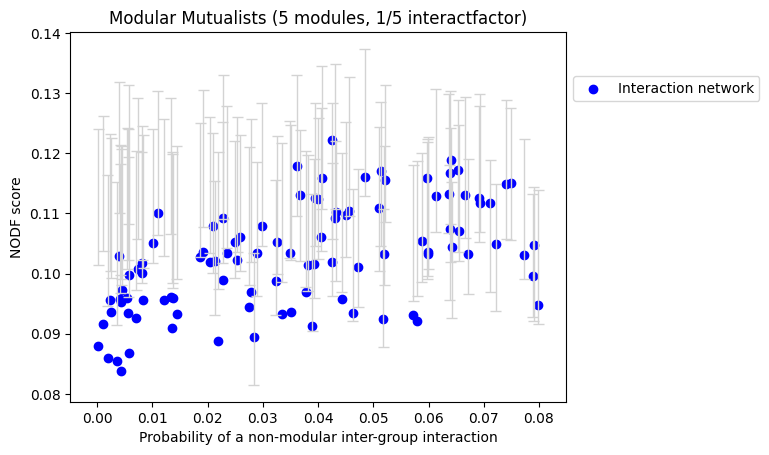

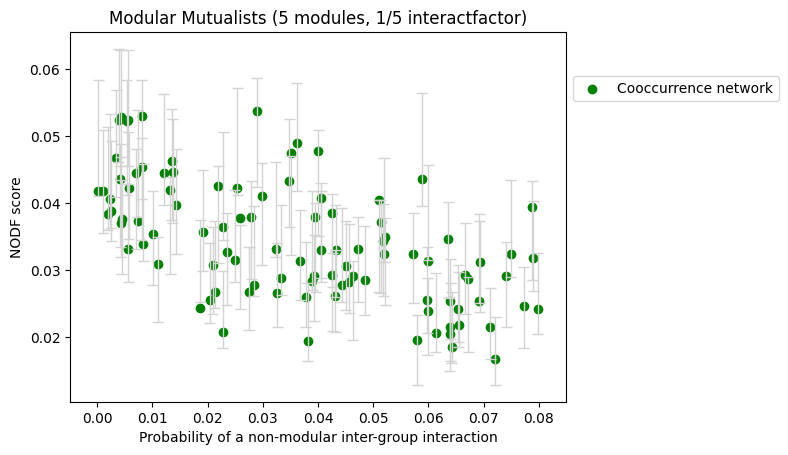

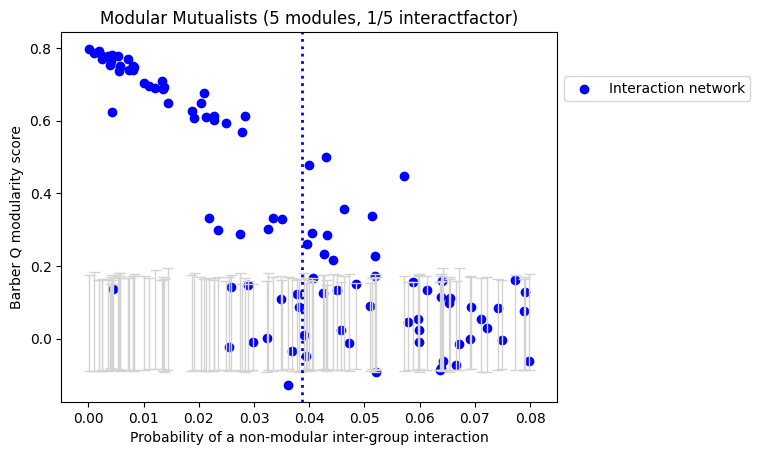

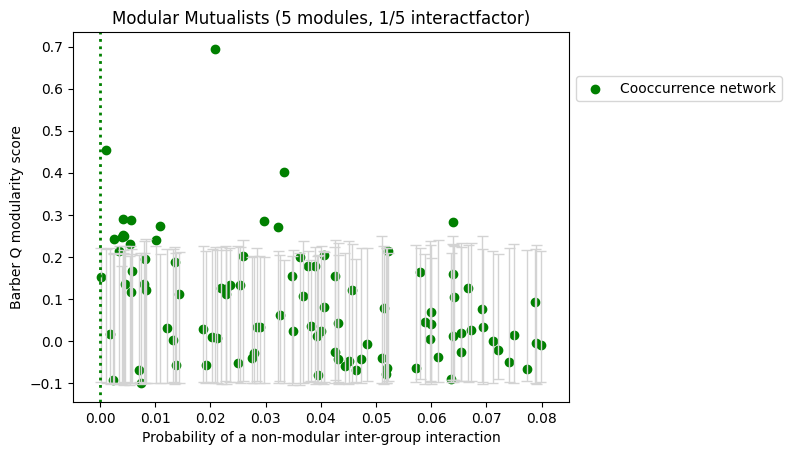

In [283]:
#Code to classify MODULAR MUTUALIST networks (5 modules, 1/5 interact factor) as significantly modular, significantly nested, or neither. 

numits = 100
displacements = np.random.uniform(low=0, high = 0.08, size=numits)

nodf_int_vec_5modmutual = np.zeros((len(displacements)))
nodf_int_low_5modmutual = np.zeros((len(displacements)))
nodf_int_high_5modmutual = np.zeros((len(displacements)))

barber_int_vec_5modmutual = np.zeros((len(displacements)))
barber_int_low_5modmutual = np.zeros((len(displacements)))
barber_int_high_5modmutual = np.zeros((len(displacements)))

nodf_cooc_vec_5modmutual = np.zeros((len(displacements)))
nodf_cooc_low_5modmutual = np.zeros((len(displacements)))
nodf_cooc_high_5modmutual = np.zeros((len(displacements)))

barber_cooc_vec_5modmutual = np.zeros((len(displacements)))
barber_cooc_low_5modmutual = np.zeros((len(displacements)))
barber_cooc_high_5modmutual = np.zeros((len(displacements)))


#params for all simulations

nSpecies = 100
interactFactor = 1/5
pPositive = 0.5
pIntraInteract = 0.05

# params for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
group_size = int(0.5*nSpecies)
modulefrac = 1/5

mod_size = modulefrac*group_size
num_mod = group_size/mod_size
edge_tot = (group_size)**2
edge_mod = num_mod*((mod_size)**2)


for i in range(len(displacements)):

    print(i)
    change_mod = ((edge_tot - edge_mod)/edge_mod)*displacements[i]

    pInterInteract = 0.5-change_mod
    pInterInteract_off = displacements[i]
    
    mod_mutual = metaCommunityMx.getModularMutual(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive, modulefrac)
    #BELOW IS ALWAYS POSITIVE
    modonly_int = (abs(mod_mutual[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if interaction network is significantly nested
    nodf_int_vec_5modmutual[i] = metrics_and_plotting.calculate_nodf(modonly_int)
    barber_int_vec_5modmutual[i] = barberfrom_matrix(modonly_int,group_size)
    nodf_int_low_5modmutual[i], nodf_int_high_5modmutual[i], barber_int_low_5modmutual[i], barber_int_high_5modmutual[i] = nodf_barberq_intervals(modonly_int, group_size)

    #Get co-occurrence network, make similar calculations
    network_cooccmod, G_mod_coocc = run_cooccurrence.get_coocc_network(interactionMx = mod_mutual, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 150)
    modonly_cooc = (abs(network_cooccmod[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if cooccurrence network is significantly nested
    nodf_cooc_vec_5modmutual[i] = metrics_and_plotting.calculate_nodf(modonly_cooc)
    barber_cooc_vec_5modmutual[i] = barberfrom_matrix(modonly_cooc,group_size)
    nodf_cooc_low_5modmutual[i], nodf_cooc_high_5modmutual[i], barber_cooc_low_5modmutual[i], barber_cooc_high_5modmutual[i] = nodf_barberq_intervals(modonly_cooc, group_size)


interact_fitted_5modmutual, interaction_threshold = threshold_sigstructure(displacements, barber_int_vec_5modmutual, barber_int_high_5modmutual)
cooc_fitted_5modmutual, cooc_threshold = threshold_sigstructure(displacements, barber_cooc_vec_5modmutual, barber_cooc_high_5modmutual)


plt.scatter(displacements, nodf_int_vec_5modmutual, color = 'b', label = 'Interaction network')
plot_interval(displacements, nodf_int_low_5modmutual, nodf_int_high_5modmutual)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Mutualists (5 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, nodf_cooc_vec_5modmutual, color='g', label = 'Cooccurrence network')
plot_interval(displacements, nodf_cooc_low_5modmutual, nodf_cooc_high_5modmutual)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Mutualists (5 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_int_vec_5modmutual, color = 'b', label = 'Interaction network')
plot_interval(displacements, barber_int_low_5modmutual, barber_int_high_5modmutual)
plt.axvline(x=interaction_threshold, color='b', linestyle='dotted', linewidth=2)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Mutualists (5 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_cooc_vec_5modmutual, color='g', label = 'Cooccurrence network')
plot_interval(displacements, barber_cooc_low_5modmutual, barber_cooc_high_5modmutual)
plt.axvline(x=cooc_threshold, color='g', linestyle='dotted', linewidth=2)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Mutualists (5 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


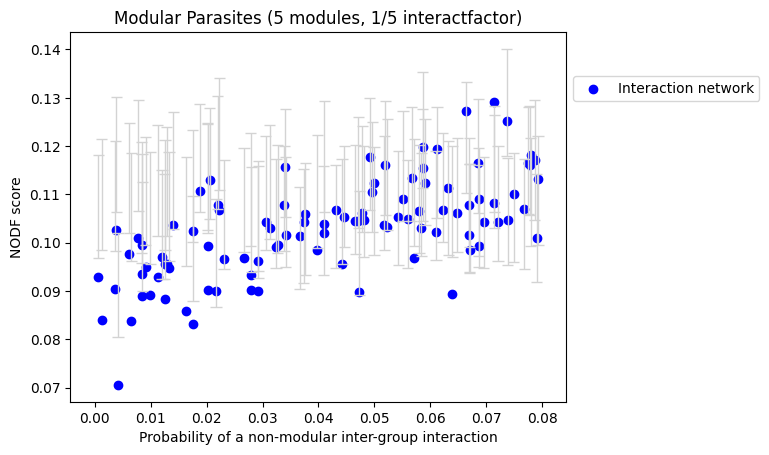

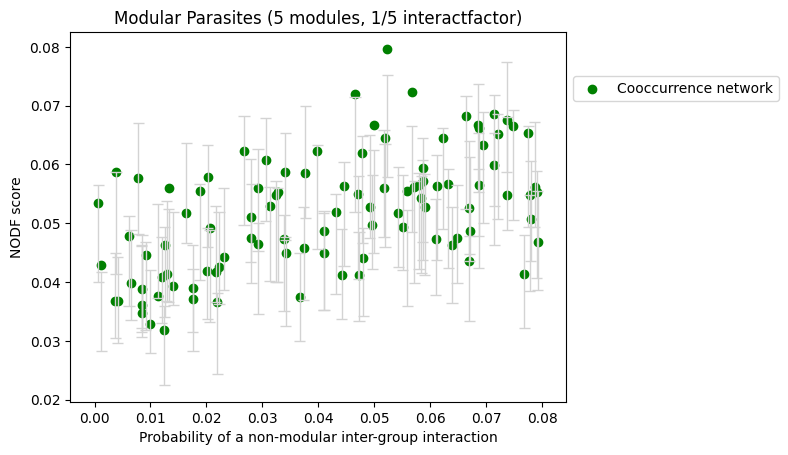

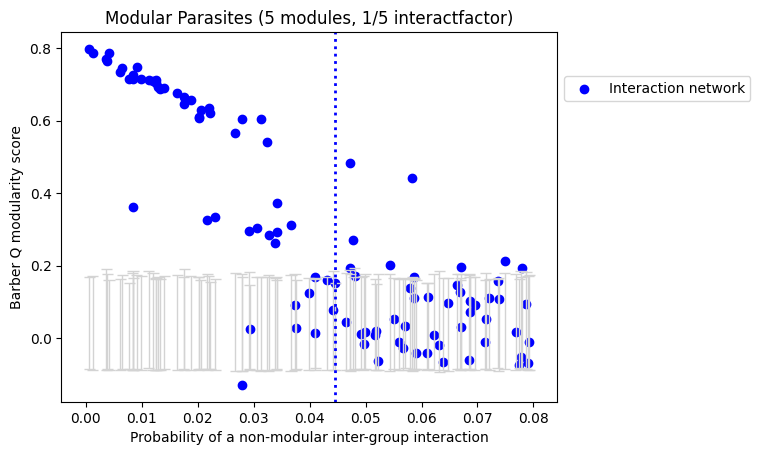

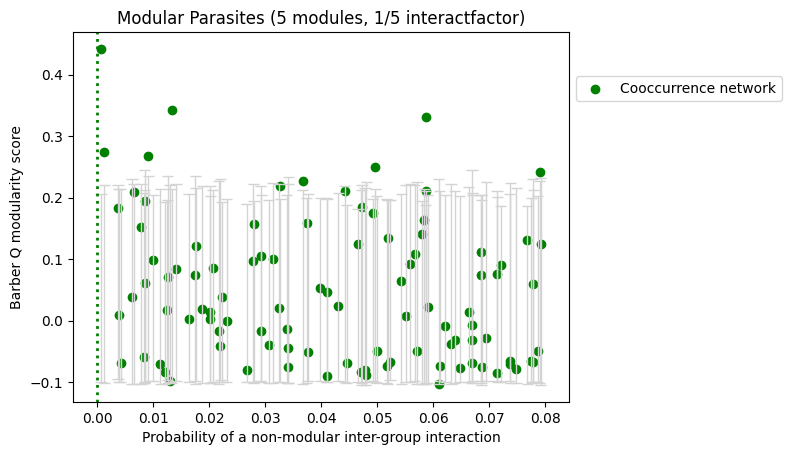

In [284]:
#Code to classify MODULAR PARASITE networks (5 modules) as significantly modular, significantly nested, or neither. 

numits = 100
displacements = np.random.uniform(low=0, high=0.08, size=numits)

nodf_int_vec_5modpar = np.zeros((len(displacements)))
nodf_int_low_5modpar = np.zeros((len(displacements)))
nodf_int_high_5modpar = np.zeros((len(displacements)))

barber_int_vec_5modpar = np.zeros((len(displacements)))
barber_int_low_5modpar = np.zeros((len(displacements)))
barber_int_high_5modpar = np.zeros((len(displacements)))

nodf_cooc_vec_5modpar = np.zeros((len(displacements)))
nodf_cooc_low_5modpar = np.zeros((len(displacements)))
nodf_cooc_high_5modpar = np.zeros((len(displacements)))

barber_cooc_vec_5modpar = np.zeros((len(displacements)))
barber_cooc_low_5modpar = np.zeros((len(displacements)))
barber_cooc_high_5modpar = np.zeros((len(displacements)))


#params for all simulations

nSpecies = 100
interactFactor = 1/5
pPositive = 0.5
pIntraInteract = 0.05

# params for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
group_size = int(0.5*nSpecies)
modulefrac = 1/5

mod_size = modulefrac*group_size
num_mod = group_size/mod_size
edge_tot = (group_size)**2
edge_mod = num_mod*((mod_size)**2)

change_mod = ((edge_tot - edge_mod)/edge_mod)*displacements

for i in range(len(displacements)):

    print(i)
    #change_mod = ((edge_tot - edge_mod)/edge_mod)*displacements[i]

    pInterInteract = 0.5-change_mod[i]
    pInterInteract_off = displacements[i]
    
    mod_parasite = metaCommunityMx.getModularParasite(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive, modulefrac)
    #BELOW IS ALWAYS POSITIVE
    modonly_int = (abs(mod_parasite[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if interaction network is significantly nested
    nodf_int_vec_5modpar[i] = metrics_and_plotting.calculate_nodf(modonly_int)
    barber_int_vec_5modpar[i] = barberfrom_matrix(modonly_int,group_size)
    nodf_int_low_5modpar[i], nodf_int_high_5modpar[i],barber_int_low_5modpar[i], barber_int_high_5modpar[i] = nodf_barberq_intervals(modonly_int, group_size)

    #Get co-occurrence network, make similar calculations
    network_cooccmod, G_mod_coocc = run_cooccurrence.get_coocc_network(interactionMx = mod_parasite, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 150)
    modonly_cooc = (abs(network_cooccmod[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if cooccurrence network is significantly nested
    nodf_cooc_vec_5modpar[i] = metrics_and_plotting.calculate_nodf(modonly_cooc)
    barber_cooc_vec_5modpar[i] = barberfrom_matrix(modonly_cooc,group_size)
    nodf_cooc_low_5modpar[i], nodf_cooc_high_5modpar[i],barber_cooc_low_5modpar[i], barber_cooc_high_5modpar[i]  = nodf_barberq_intervals(modonly_cooc, group_size)


interact_fitted_5modpar, interaction_threshold = threshold_sigstructure(displacements, barber_int_vec_5modpar, barber_int_high_5modpar)
cooc_fitted_5modpar, cooc_threshold = threshold_sigstructure(displacements, barber_cooc_vec_5modpar, barber_cooc_high_5modpar)


plt.scatter(displacements, nodf_int_vec_5modpar, color = 'b', label = 'Interaction network')
plot_interval(displacements, nodf_int_low_5modpar, nodf_int_high_5modpar)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Parasites (5 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, nodf_cooc_vec_5modpar, color='g', label = 'Cooccurrence network')
plot_interval(displacements, nodf_cooc_low_5modpar, nodf_cooc_high_5modpar)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Parasites (5 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_int_vec_5modpar, color = 'b', label = 'Interaction network')
plot_interval(displacements, barber_int_low_5modpar, barber_int_high_5modpar,color='lightgrey')
plt.axvline(x=interaction_threshold, color='b', linestyle='dotted', linewidth=2)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Parasites (5 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_cooc_vec_5modpar, color='g', label = 'Cooccurrence network')
plot_interval(displacements, barber_cooc_low_5modpar, barber_cooc_high_5modpar, color = 'lightgrey')
plt.axvline(x=cooc_threshold, color='g', linestyle='dotted', linewidth=2)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Parasites (5 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -38.037
Date:                Wed, 11 Feb 2026   Deviance:                       76.074
Time:                        17:13:33   Pearson chi2:                     82.7
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4272

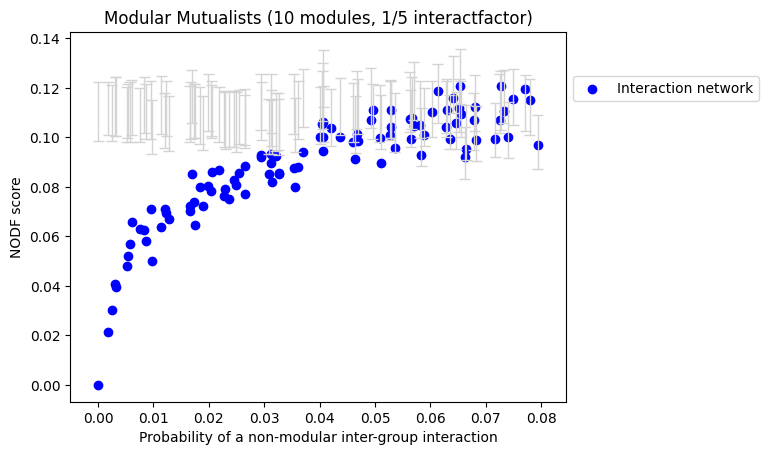

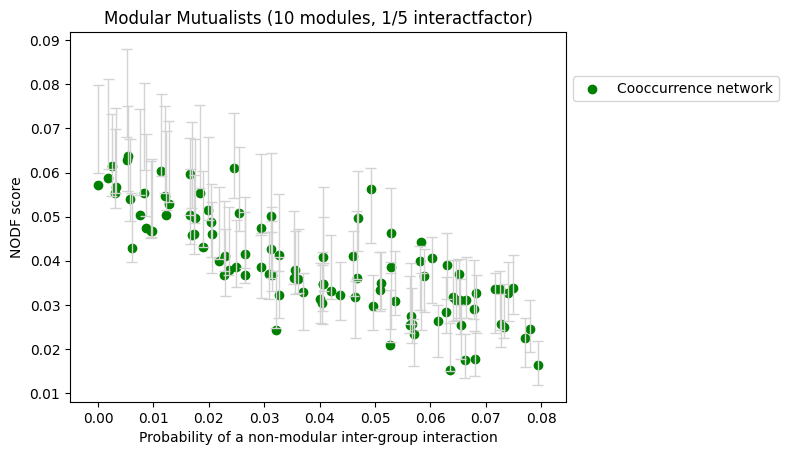

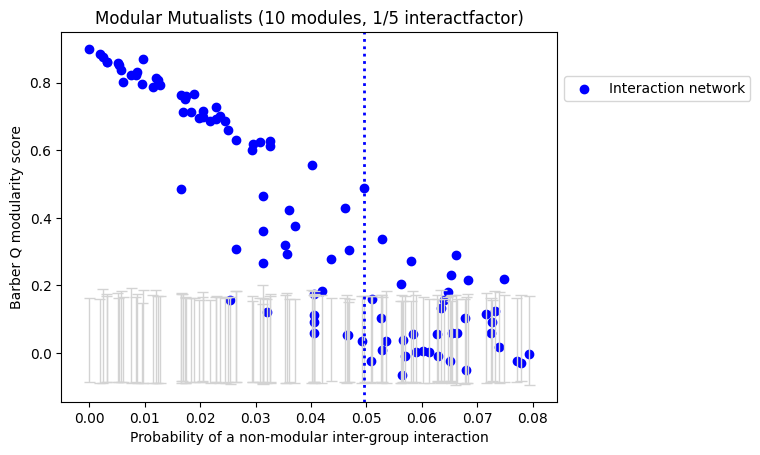

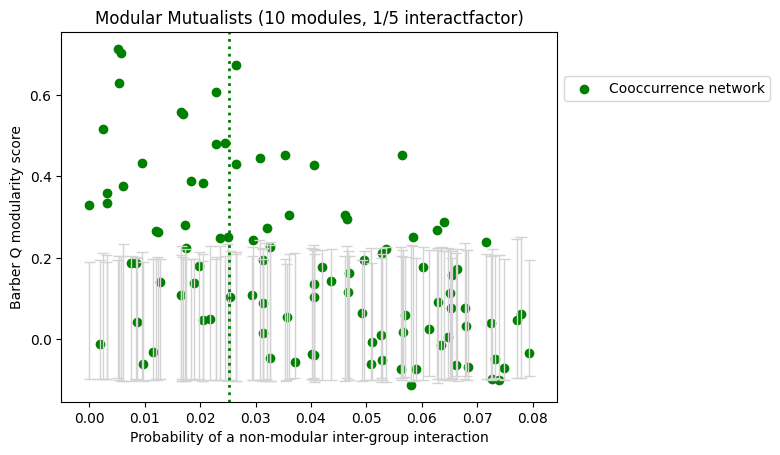

In [ ]:
#Code to classify MODULAR MUTUALIST networks (10 modules) as significantly modular, significantly nested, or neither. 

numits = 100
displacements = np.random.uniform(low=0, high=0.08, size=numits)

nodf_int_vec_10modmutual = np.zeros((len(displacements)))
nodf_int_low_10modmutual = np.zeros((len(displacements)))
nodf_int_high_10modmutual = np.zeros((len(displacements)))

barber_int_vec_10modmutual = np.zeros((len(displacements)))
barber_int_low_10modmutual = np.zeros((len(displacements)))
barber_int_high_10modmutual = np.zeros((len(displacements)))

nodf_cooc_vec_10modmutual = np.zeros((len(displacements)))
nodf_cooc_low_10modmutual = np.zeros((len(displacements)))
nodf_cooc_high_10modmutual = np.zeros((len(displacements)))

barber_cooc_vec_10modmutual = np.zeros((len(displacements)))
barber_cooc_low_10modmutual = np.zeros((len(displacements)))
barber_cooc_high_10modmutual = np.zeros((len(displacements)))


#params for all simulations

nSpecies = 100
interactFactor = 1/5
pPositive = 0.5
pIntraInteract = 0.05

# params for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
group_size = int(0.5*nSpecies)
modulefrac = 1/10

mod_size = modulefrac*group_size
num_mod = group_size/mod_size
edge_tot = (group_size)**2
edge_mod = num_mod*((mod_size)**2)


for i in range(len(displacements)):

    print(i)
    change_mod = ((edge_tot - edge_mod)/edge_mod)*displacements[i]

    pInterInteract = 1-change_mod
    pInterInteract_off = displacements[i]
    
    mod_mutual = metaCommunityMx.getModularMutual(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive, modulefrac)
    #BELOW IS ALWAYS POSITIVE
    modonly_int = (abs(mod_mutual[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if interaction network is significantly nested
    nodf_int_vec_10modmutual[i] = metrics_and_plotting.calculate_nodf(modonly_int)
    barber_int_vec_10modmutual[i] = barberfrom_matrix(modonly_int,group_size)
    nodf_int_low_10modmutual[i], nodf_int_high_10modmutual[i],barber_int_low_10modmutual[i], barber_int_high_10modmutual[i] = nodf_barberq_intervals(modonly_int,group_size)
    
    #Get co-occurrence network, make similar calculations
    network_cooccmod, G_mod_coocc = run_cooccurrence.get_coocc_network(interactionMx = mod_mutual, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 150)
    modonly_cooc = (abs(network_cooccmod[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if cooccurrence network is significantly nested
    nodf_cooc_vec_10modmutual[i] = metrics_and_plotting.calculate_nodf(modonly_cooc)
    barber_cooc_vec_10modmutual[i] = barberfrom_matrix(modonly_cooc,group_size)
    nodf_cooc_low_10modmutual[i], nodf_cooc_high_10modmutual[i],barber_cooc_low_10modmutual[i], barber_cooc_high_10modmutual[i] = nodf_barberq_intervals(modonly_cooc, group_size)


interact_fitted_10modmutual, interaction_threshold_10modmutual = threshold_sigstructure(displacements, barber_int_vec_10modmutual, barber_int_high_10modmutual)
cooc_fitted_10modmutual, cooc_threshold_10modmutual = threshold_sigstructure(displacements, barber_cooc_vec_10modmutual, barber_cooc_high_10modmutual)

print(interact_fitted_10modmutual.summary())
print(cooc_fitted_10modmutual.summary())
print(interaction_threshold_10modmutual)
print(cooc_threshold_10modmutual)


plt.scatter(displacements, nodf_int_vec_10modmutual, color = 'b', label = 'Interaction network')
plot_interval(displacements, nodf_int_low_10modmutual, nodf_int_high_10modmutual)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Mutualists (10 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, nodf_cooc_vec_10modmutual, color='g', label = 'Cooccurrence network')
plot_interval(displacements, nodf_cooc_low_10modmutual, nodf_cooc_high_10modmutual)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Mutualists (10 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_int_vec_10modmutual, color = 'b', label = 'Interaction network')
plot_interval(displacements, barber_int_low_10modmutual, barber_int_high_10modmutual)
plt.axvline(x=interaction_threshold_10modmutual, color='b', linestyle='dotted', linewidth=2)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Mutualists (10 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_cooc_vec_10modmutual, color='g', label = 'Cooccurrence network')
plot_interval(displacements, barber_cooc_low_10modmutual, barber_cooc_high_10modmutual)
plt.axvline(x=cooc_threshold_10modmutual, color='g', linestyle='dotted', linewidth=2)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Mutualists (10 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -38.434
Date:                Fri, 13 Feb 2026   Deviance:                       76.869
Time:                        11:23:28   Pearson chi2:                     90.0
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4588

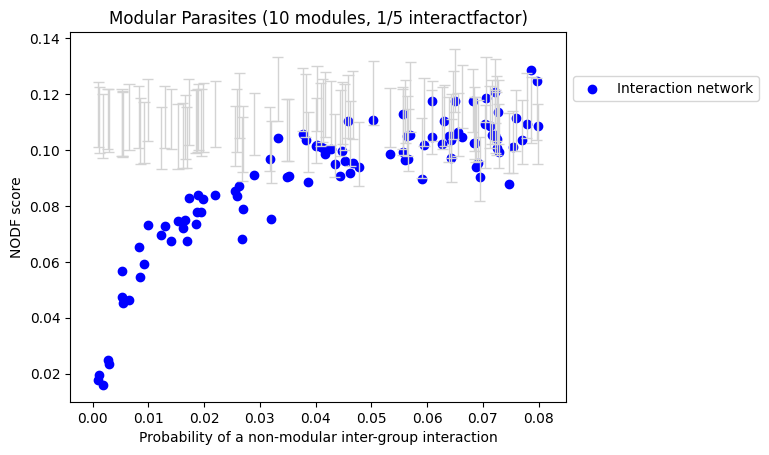

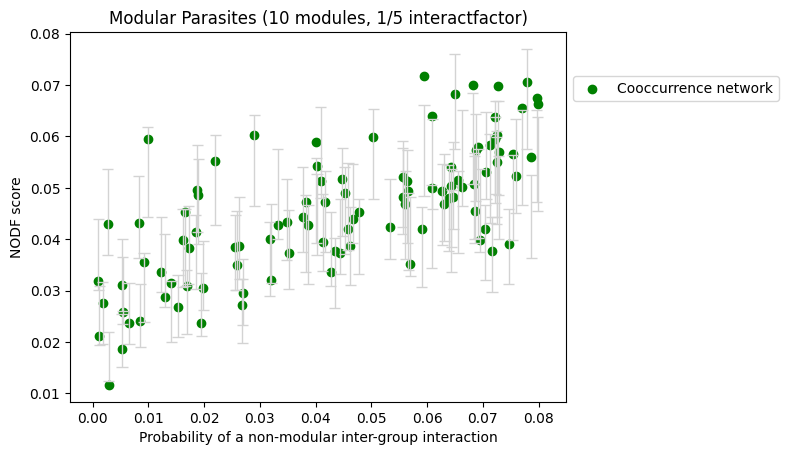

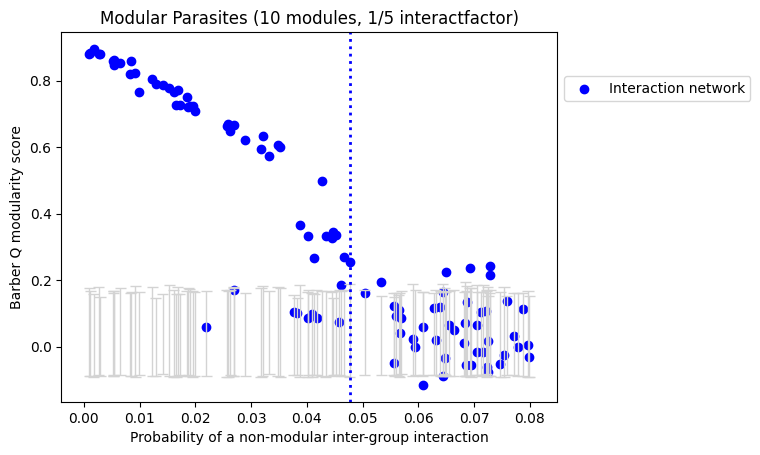

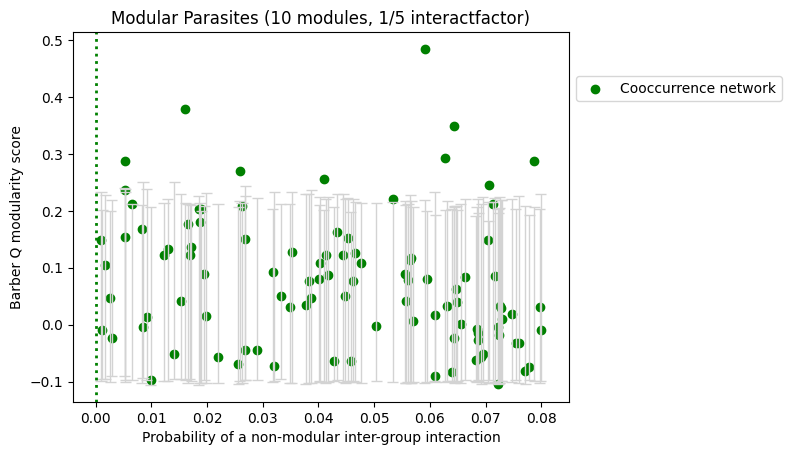

In [222]:
#Code to classify MODULAR PARASITE networks (10 modules) as significantly modular, significantly nested, or neither. 

numits = 100
displacements = np.random.uniform(low=0, high=0.08, size=numits)

nodf_int_vec_10modpar = np.zeros((len(displacements)))
nodf_int_low_10modpar = np.zeros((len(displacements)))
nodf_int_high_10modpar = np.zeros((len(displacements)))

barber_int_vec_10modpar = np.zeros((len(displacements)))
barber_int_low_10modpar = np.zeros((len(displacements)))
barber_int_high_10modpar = np.zeros((len(displacements)))

nodf_cooc_vec_10modpar = np.zeros((len(displacements)))
nodf_cooc_low_10modpar = np.zeros((len(displacements)))
nodf_cooc_high_10modpar = np.zeros((len(displacements)))

barber_cooc_vec_10modpar = np.zeros((len(displacements)))
barber_cooc_low_10modpar = np.zeros((len(displacements)))
barber_cooc_high_10modpar = np.zeros((len(displacements)))


#params for all simulations

nSpecies = 100
interactFactor = 1/5
pPositive = 0.5
pIntraInteract = 0.05

# params for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
group_size = int(0.5*nSpecies)
modulefrac = 1/10

mod_size = modulefrac*group_size
num_mod = group_size/mod_size
edge_tot = (group_size)**2
edge_mod = num_mod*((mod_size)**2)


for i in range(len(displacements)):

    print(i)
    change_mod = ((edge_tot - edge_mod)/edge_mod)*displacements[i]

    pInterInteract = 1-change_mod
    pInterInteract_off = displacements[i]
    
    mod_parasite = metaCommunityMx.getModularParasite(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive, modulefrac)
    #BELOW IS ALWAYS POSITIVE
    modonly_int = (abs(mod_parasite[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if interaction network is significantly nested
    nodf_int_vec_10modpar[i] = metrics_and_plotting.calculate_nodf(modonly_int)
    barber_int_vec_10modpar[i] = barberfrom_matrix(modonly_int,group_size)
    nodf_int_low_10modpar[i], nodf_int_high_10modpar[i],barber_int_low_10modpar[i], barber_int_high_10modpar[i] = nodf_barberq_intervals(modonly_int, group_size)

    #Get co-occurrence network, make similar calculations
    network_cooccmod, G_mod_coocc = run_cooccurrence.get_coocc_network(interactionMx = mod_parasite, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 150)
    modonly_cooc = (abs(network_cooccmod[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if cooccurrence network is significantly nested
    nodf_cooc_vec_10modpar[i] = metrics_and_plotting.calculate_nodf(modonly_cooc)
    barber_cooc_vec_10modpar[i] = barberfrom_matrix(modonly_cooc,group_size)
    nodf_cooc_low_10modpar[i], nodf_cooc_high_10modpar[i],barber_cooc_low_10modpar[i], barber_cooc_high_10modpar[i] = nodf_barberq_intervals(modonly_cooc, group_size)


interact_fitted_10modpar, interaction_threshold_10modpar = threshold_sigstructure(displacements, barber_int_vec_10modpar, barber_int_high_10modpar)
cooc_fitted_10modpar, cooc_threshold_10modpar = threshold_sigstructure(displacements, barber_cooc_vec_10modpar, barber_cooc_high_10modpar)

print(interact_fitted_10modpar.summary())
print(cooc_fitted_10modpar.summary())
print(interaction_threshold_10modpar)
print(cooc_threshold_10modpar)

plt.scatter(displacements, nodf_int_vec_10modpar, color = 'b', label = 'Interaction network')
plot_interval(displacements, nodf_int_low_10modpar, nodf_int_high_10modpar)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Parasites (10 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, nodf_cooc_vec_10modpar, color='g', label = 'Cooccurrence network')
plot_interval(displacements, nodf_cooc_low_10modpar, nodf_cooc_high_10modpar)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Parasites (10 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_int_vec_10modpar, color = 'b', label = 'Interaction network')
plot_interval(displacements, barber_int_low_10modpar, barber_int_high_10modpar)
plt.axvline(x=interaction_threshold_10modpar, color='b', linestyle='dotted', linewidth=2)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Parasites (10 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, barber_cooc_vec_10modpar, color='g', label = 'Cooccurrence network')
plot_interval(displacements, barber_cooc_low_10modpar, barber_cooc_high_10modpar)
plt.axvline(x=cooc_threshold_10modpar, color='g', linestyle='dotted', linewidth=2)
plt.ylabel('Barber Q modularity score')
plt.xlabel('Probability of a non-modular inter-group interaction')
plt.title('Modular Parasites (10 modules, 1/5 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


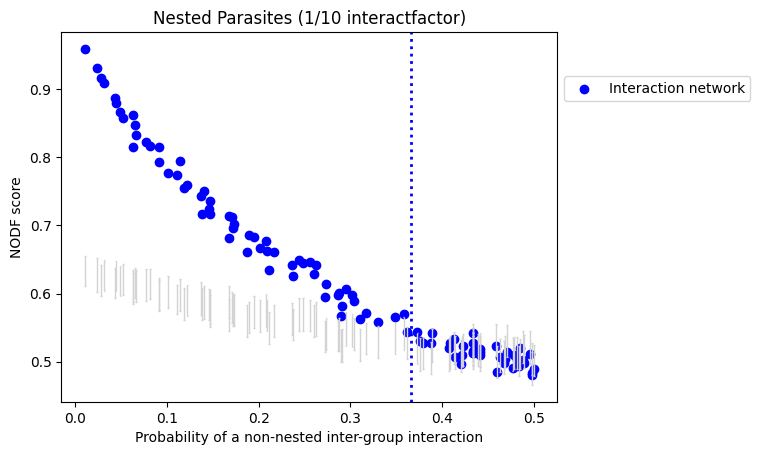

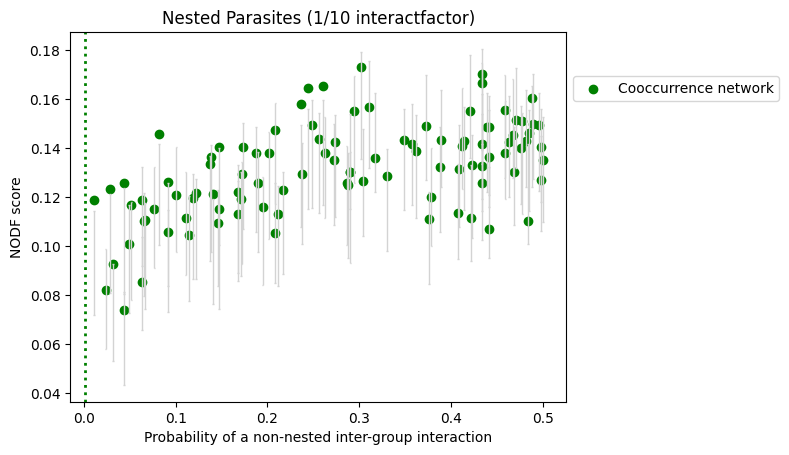

In [ ]:
#PRC null model
#Code to classify NESTED PARASITE networks as significantly modular, significantly nested, or neither. 


numits = 100
displacements = np.random.uniform(low=0.01, high = 0.5, size=numits)

nodf_int_vec_nestedparasite = np.zeros((len(displacements)))
nodf_int_low_nestedparasite = np.zeros((len(displacements)))
nodf_int_high_nestedparasite = np.zeros((len(displacements)))

nodf_cooc_vec_nestedparasite = np.zeros((len(displacements)))
nodf_cooc_low_nestedparasite = np.zeros((len(displacements)))
nodf_cooc_high_nestedparasite = np.zeros((len(displacements)))

#params for all simulations

nSpecies = 100
interactFactor = 1/10
pPositive = 0.2
pIntraInteract = 0.1

# params for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpecies) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpecies) - np.random.uniform(low = 0, high = .1, size = (nSpecies))
group_size = int(0.5*nSpecies)


##CODE FOR NESTED PARASITE NETWORK

for i in range(len(displacements)):

    print(i)
    pInterInteract = 1-displacements[i]
    pInterInteract_off = displacements[i]
    
    nestedparasite = metaCommunityMx.getNestedParasite(interactStren,nSpecies,pInterInteract,pInterInteract_off, pIntraInteract,pPositive)
    nestedonly_int = (abs(nestedparasite[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if interaction network is significantly nested
    nodf_int_vec_nestedparasite[i] = metrics_and_plotting.calculate_nodf(nestedonly_int)
    nodf_int_low_nestedparasite[i], nodf_int_high_nestedparasite[i] = nodf_interval_prc(nestedonly_int)
    
    #Get co-occurrence network, make similar calculations
    network_cooccnest, G_nest_coocc = run_cooccurrence.get_coocc_network(interactionMx = nestedparasite, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, tmax = 150)
    nestedonly_cooc = (abs(network_cooccnest[0:group_size, group_size:nSpecies])>0).astype(int)

    #check if cooccurrence network is significantly nested
    nodf_cooc_vec_nestedparasite[i] = metrics_and_plotting.calculate_nodf(nestedonly_cooc)
    nodf_cooc_low_nestedparasite[i], nodf_cooc_high_nestedparasite[i]= nodf_interval_prc(nestedonly_cooc)


interact_fitted_nestedparasite, interaction_threshold_nestpar = threshold_sigstructure(displacements, nodf_int_vec_nestedparasite, nodf_int_high_nestedparasite)
cooc_fitted_nestedparasite, cooc_threshold_nestpar = threshold_sigstructure(displacements, nodf_cooc_vec_nestedparasite, nodf_cooc_high_nestedparasite)

plt.scatter(displacements, nodf_int_vec_nestedparasite, color = 'b', label = 'Interaction network')
plot_interval(displacements, nodf_int_low_nestedparasite, nodf_int_high_nestedparasite)
plt.axvline(x=interaction_threshold_nestpar, color='b', linestyle='dotted', linewidth=2)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-nested inter-group interaction')
plt.title('Nested Parasites (1/10 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

plt.scatter(displacements, nodf_cooc_vec_nestedparasite, color='g', label = 'Cooccurrence network')
plot_interval(displacements, nodf_cooc_low_nestedparasite, nodf_cooc_high_nestedparasite)
plt.axvline(x=cooc_threshold_nestpar, color='g', linestyle='dotted', linewidth=2)
plt.ylabel('NODF score')
plt.xlabel('Probability of a non-nested inter-group interaction')
plt.title('Nested Parasites (1/10 interactfactor)')
plt.legend(bbox_to_anchor=(1, 0.9), loc='upper left', ncol=1)
plt.show()

